# 🌍 Earthquake Risk Classification using Machine Learning

## Objectif du projet

L’objectif de ce projet est d’analyser les données sismiques fournies par l'USGS (United States Geological Survey) afin de construire un système intelligent capable de classifier les séismes selon leur niveau de gravité.

Le projet suit un pipeline complet de Data Science :

1. Chargement et exploration des données
2. Nettoyage et traitement des valeurs manquantes
3. Détection et traitement des valeurs aberrantes
4. Création de nouvelles variables (Feature Engineering)
5. Analyse exploratoire des données (EDA)
6. Sélection et préparation des variables
7. Entraînement de plusieurs modèles de Machine Learning
8. Comparaison des performances
9. Sélection du meilleur modèle pour la prédiction du risque sismique

Les données utilisées proviennent de l’API USGS et contiennent des informations géographiques, temporelles et sismologiques sur les tremblements de terre observés dans le monde.

## 1️⃣ Chargement des données

Dans cette étape, nous importons le dataset contenant les informations relatives aux séismes enregistrés par l'USGS.

L'objectif est de charger les données dans un DataFrame Pandas afin de commencer leur analyse et leur préparation.

In [1]:
import pandas as pd

# Lire le fichier CSV
df = pd.read_csv('usgs_earthquakes.csv')



# Nettoyage et préparation 

## 2️⃣ Compréhension du dataset

Avant tout traitement, il est important de comprendre la structure générale des données :

- Nombre de lignes et de colonnes
- Types de variables
- Description statistique
- Présence éventuelle de valeurs manquantes

In [2]:
df.head()

,id,time_utc,updated_utc,longitude,latitude,depth_km,place,mag,magType,nst,...,alert,tsunami,sig,status,type,horizontalError,depthError,magError,magNst,url
0,us6000svgp,2026-05-05 23:10:51,2026-05-06 00:01:05,126.8824,7.9301,35.00,"45 km NE of Kinablangan, Philippines",4.6,mb,22.0,...,NaN,0,326,reviewed,earthquake,NaN,NaN,NaN,NaN,https://earthquake.usgs.gov/earthquakes/eventp...
1,us6000svgl,2026-05-05 23:02:33,2026-05-06 01:09:37,15.4546,39.8560,298.62,"18 km SSE of Marina di Camerota, Italy",4.1,mb,37.0,...,NaN,0,259,reviewed,earthquake,NaN,NaN,NaN,NaN,https://earthquake.usgs.gov/earthquakes/eventp...
2,aka2026iwurap,2026-05-05 22:57:40,2026-05-06 00:57:42,-153.0290,60.3940,141.60,"74 km ENE of Port Alsworth, Alaska",3.5,ml,219.0,...,NaN,0,188,reviewed,earthquake,NaN,NaN,NaN,NaN,https://earthquake.usgs.gov/earthquakes/eventp...
3,aka2026iwupmw,2026-05-05 22:55:56,2026-05-06 08:20:03,-149.7790,61.4940,28.10,"4 km NNW of Knik, Alaska",2.9,ml,45.0,...,NaN,0,129,automatic,earthquake,NaN,NaN,NaN,NaN,https://earthquake.usgs.gov/earthquakes/eventp...
4,aka2026iwtbux,2026-05-05 22:10:10,2026-05-05 23:14:46,-150.8770,61.5240,57.90,"19 km W of Susitna, Alaska",2.5,ml,56.0,...,NaN,0,96,automatic,earthquake,NaN,NaN,NaN,NaN,https://earthquake.usgs.gov/earthquakes/eventp...


In [3]:
df.shape

(136457, 27)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 136457 entries, 0 to 136456
Data columns (total 27 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   id               136457 non-null  object 
 1   time_utc         136457 non-null  object 
 2   updated_utc      136457 non-null  object 
 3   longitude        136457 non-null  float64
 4   latitude         136457 non-null  float64
 5   depth_km         136457 non-null  float64
 6   place            136457 non-null  object 
 7   mag              136457 non-null  float64
 8   magType          136457 non-null  object 
 9   nst              108601 non-null  float64
 10  gap              128422 non-null  float64
 11  dmin             125343 non-null  float64
 12  rms              136447 non-null  float64
 13  net              136457 non-null  object 
 14  felt             21926 non-null   float64
 15  cdi              21926 non-null   float64
 16  mmi              9157 non-null    floa

In [5]:
df.describe()

,longitude,latitude,depth_km,mag,nst,gap,dmin,rms,felt,cdi,mmi,tsunami,sig,horizontalError,depthError,magError,magNst
count,136457.000000,136457.000000,136457.000000,136457.000000,108601.000000,128422.000000,125343.000000,136447.000000,21926.000000,21926.000000,9157.000000,136457.000000,136457.000000,0.0,0.0,0.0,0.0
mean,-23.648890,20.004449,61.184445,3.873978,41.591136,129.612028,2.622709,0.593207,81.233923,3.047542,3.254663,0.004514,244.868852,NaN,NaN,NaN,NaN
std,129.333789,31.622450,110.614559,0.855948,37.005528,69.129192,4.126008,0.283528,1520.639580,1.410841,1.591944,0.067037,109.343306,NaN,NaN,NaN,NaN
min,-179.999700,-84.493200,-3.740000,2.500000,0.000000,8.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,96.000000,NaN,NaN,NaN,NaN
25%,-151.951900,-5.110800,10.000000,3.000000,19.000000,74.000000,0.490000,0.400000,1.000000,2.000000,2.331000,0.000000,138.000000,NaN,NaN,NaN,NaN
50%,-67.064000,23.696800,16.420000,4.200000,29.000000,117.000000,1.341000,0.600000,2.000000,3.100000,3.376000,0.000000,271.000000,NaN,NaN,NaN,NaN
75%,126.168500,51.005300,58.350000,4.500000,51.000000,177.000000,3.058000,0.780000,9.000000,3.800000,4.115000,0.000000,312.000000,NaN,NaN,NaN,NaN
max,179.999400,87.081500,681.238000,8.800000,619.000000,358.180000,62.558000,4.700000,184657.000000,9.100000,9.953000,1.000000,2910.000000,NaN,NaN,NaN,NaN


## 3️⃣ Analyse des valeurs manquantes

Cette étape permet d’identifier les colonnes contenant des données manquantes afin de déterminer la stratégie de traitement la plus adaptée.

In [6]:
df.isnull().sum()

id                      0
time_utc                0
updated_utc             0
longitude               0
latitude                0
depth_km                0
place                   0
mag                     0
magType                 0
nst                 27856
gap                  8035
dmin                11114
rms                    10
net                     0
felt               114531
cdi                114531
mmi                127300
alert              132290
tsunami                 0
sig                     0
status                  0
type                    0
horizontalError    136457
depthError         136457
magError           136457
magNst             136457
url                     0
dtype: int64

### Visualisation des valeurs manquantes

Nous utilisons une heatmap afin d'observer visuellement la distribution des données manquantes dans le dataset.

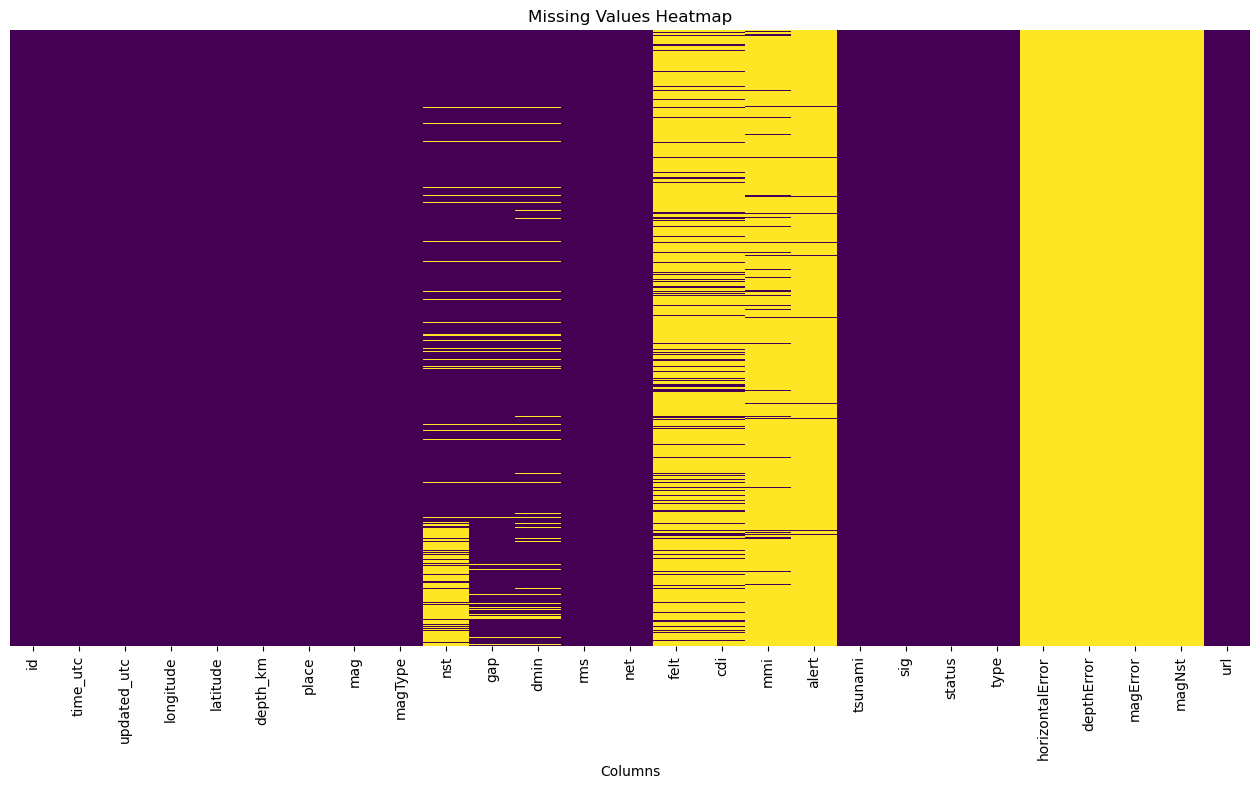

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(16,8))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title("Missing Values Heatmap")
plt.xlabel("Columns")
plt.show()

### Pourcentage des valeurs manquantes

Le calcul du pourcentage de valeurs manquantes permet d’identifier les variables fortement incomplètes pouvant être supprimées ou imputées.

In [8]:
missing_percent = df.isnull().mean()*100
print(missing_percent.sort_values(ascending=False))

magNst             100.000000
magError           100.000000
depthError         100.000000
horizontalError    100.000000
alert               96.946291
mmi                 93.289461
cdi                 83.931935
felt                83.931935
nst                 20.413757
dmin                 8.144690
gap                  5.888302
rms                  0.007328
tsunami              0.000000
id                   0.000000
status               0.000000
type                 0.000000
sig                  0.000000
net                  0.000000
time_utc             0.000000
magType              0.000000
mag                  0.000000
place                0.000000
depth_km             0.000000
latitude             0.000000
longitude            0.000000
updated_utc          0.000000
url                  0.000000
dtype: float64


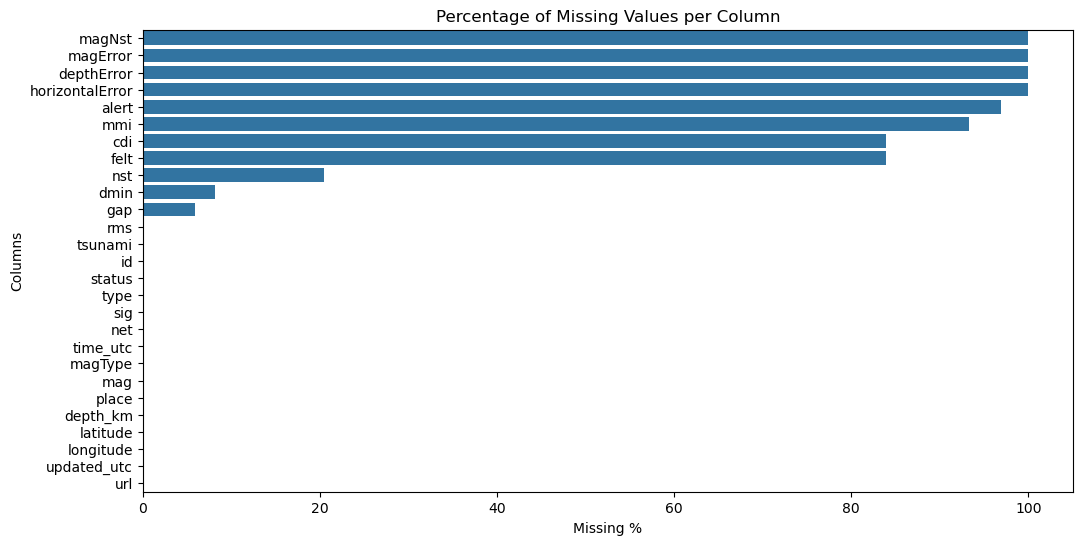

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# حساب نسبة القيم الفارغة لكل colonne
missing_percent = df.isnull().mean() * 100

# تحويلها ل DataFrame باش نسهل الرسم
missing_df = missing_percent.reset_index()
missing_df.columns = ['column', 'missing_percent']

# ترتيب من الأكبر للأصغر
missing_df = missing_df.sort_values(by='missing_percent', ascending=False)

# رسم barplot
plt.figure(figsize=(12,6))
sns.barplot(data=missing_df, x='missing_percent', y='column')

plt.title("Percentage of Missing Values per Column")
plt.xlabel("Missing %")
plt.ylabel("Columns")

plt.show()

## 4️⃣ Suppression des colonnes fortement incomplètes

Les variables contenant plus de 80 % de données manquantes apportent peu d'information et risquent de dégrader la qualité du modèle.

Elles sont donc supprimées.

In [10]:
# Colonnes à supprimer (> 80%)
cols_to_drop = missing_percent[missing_percent > 80].index

# Suppression
df_clean = df.drop(columns=cols_to_drop)

# Affichage résultat
print("Colonnes supprimées :")
print(cols_to_drop.tolist())

print("\nShape avant :", df.shape)
print("Shape après :", df_clean.shape)

Colonnes supprimées :
['felt', 'cdi', 'mmi', 'alert', 'horizontalError', 'depthError', 'magError', 'magNst']

Shape avant : (136457, 27)
Shape après : (136457, 19)


In [11]:
df = df_clean

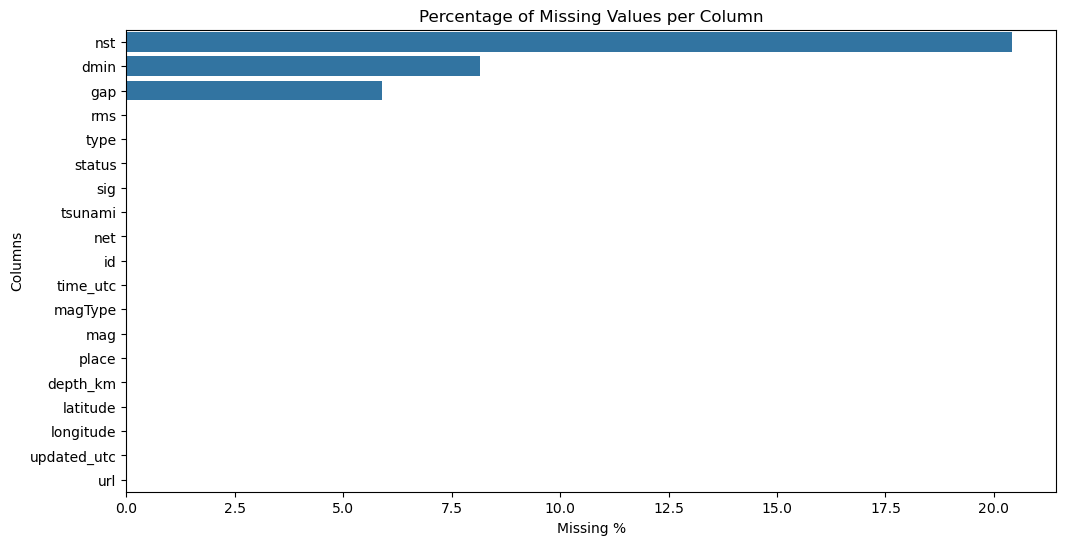

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# حساب نسبة القيم الفارغة لكل colonne
missing_percent = df.isnull().mean() * 100

# تحويلها ل DataFrame باش نسهل الرسم
missing_df = missing_percent.reset_index()
missing_df.columns = ['column', 'missing_percent']

# ترتيب من الأكبر للأصغر
missing_df = missing_df.sort_values(by='missing_percent', ascending=False)

# رسم barplot
plt.figure(figsize=(12,6))
sns.barplot(data=missing_df, x='missing_percent', y='column')

plt.title("Percentage of Missing Values per Column")
plt.xlabel("Missing %")
plt.ylabel("Columns")

plt.show()

## 5️⃣ Imputation des valeurs manquantes

Les variables numériques restantes contenant des valeurs manquantes sont complétées à l'aide de l'algorithme KNN Imputer.

Cette méthode estime les valeurs manquantes à partir des observations les plus similaires selon leur localisation géographique et leurs caractéristiques temporelles.

In [13]:
import pandas as pd
from sklearn.impute import KNNImputer

# =====================================
# COPIE DATASET
# =====================================
df = df.copy()

# =====================================
# 1. Convertir time_utc en datetime
# =====================================
df['time_utc'] = pd.to_datetime(df['time_utc'], errors='coerce')

# Extraire infos temporelles
df['year'] = df['time_utc'].dt.year
df['month'] = df['time_utc'].dt.month
df['day'] = df['time_utc'].dt.day
df['hour'] = df['time_utc'].dt.hour

# =====================================
# 2. Imputation KNN intelligente
# Basée sur :
# latitude + longitude + time
# =====================================

# ---------- GAP ----------
cols_gap = ['latitude', 'longitude', 'year', 'month', 'day', 'hour', 'gap']

imputer_gap = KNNImputer(n_neighbors=5)

df[cols_gap] = imputer_gap.fit_transform(df[cols_gap])

# ---------- RMS ----------
cols_rms = ['latitude', 'longitude', 'year', 'month', 'day', 'hour', 'rms']

imputer_rms = KNNImputer(n_neighbors=5)

df[cols_rms] = imputer_rms.fit_transform(df[cols_rms])

# ---------- DMIN ----------
cols_dmin = ['latitude', 'longitude', 'year', 'month', 'day', 'hour', 'dmin']

imputer_dmin = KNNImputer(n_neighbors=5)

df[cols_dmin] = imputer_dmin.fit_transform(df[cols_dmin])

# ---------- NST ----------
cols_nst = ['latitude', 'longitude', 'year', 'month', 'day', 'hour', 'nst']

imputer_nst = KNNImputer(n_neighbors=5)

df[cols_nst] = imputer_nst.fit_transform(df[cols_nst])



# =====================================
# Vérification
# =====================================
print(df[['gap','rms','dmin','nst']].isnull().sum())

gap     0
rms     0
dmin    0
nst     0
dtype: int64


### Vérification après imputation

Nous vérifions que toutes les valeurs manquantes ont bien été remplacées.

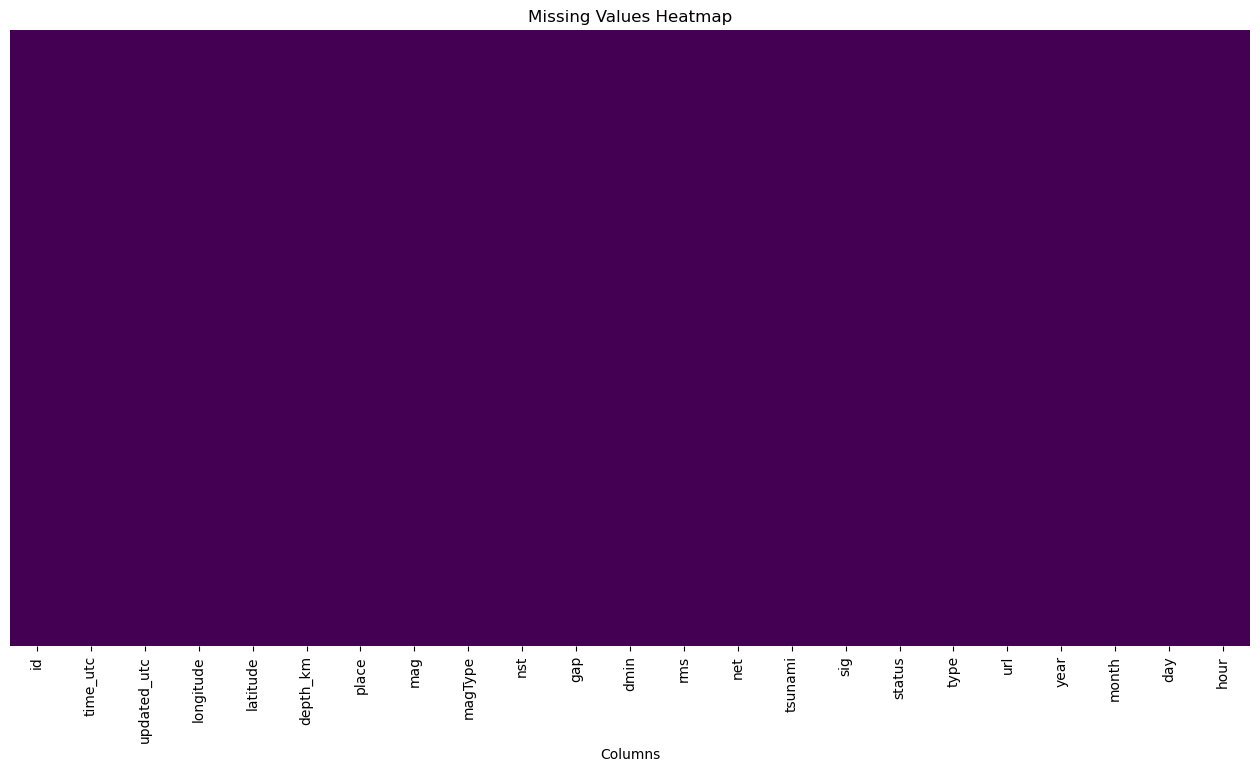

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(16,8))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title("Missing Values Heatmap")
plt.xlabel("Columns")
plt.show()

## 6️⃣ Détection des valeurs aberrantes (Outliers)

Les boxplots permettent d’identifier visuellement les observations extrêmes susceptibles d’influencer négativement l’apprentissage des modèles.

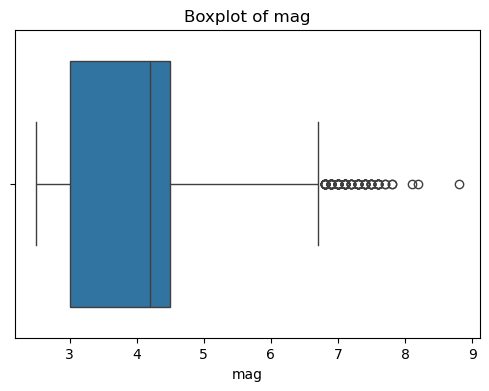

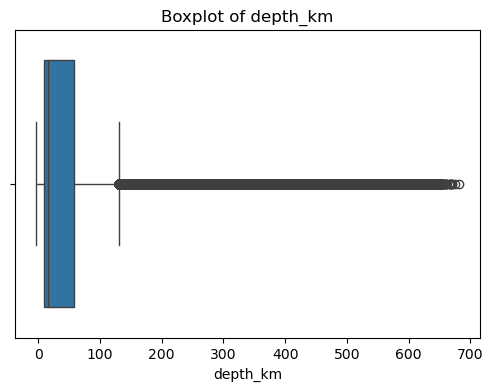

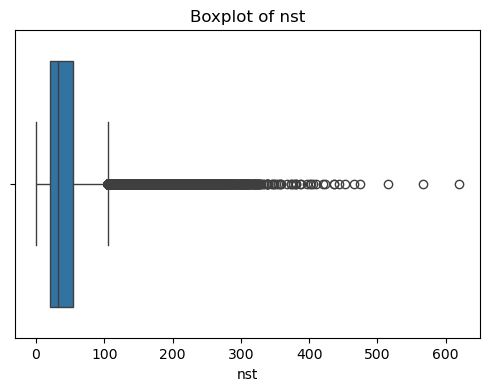

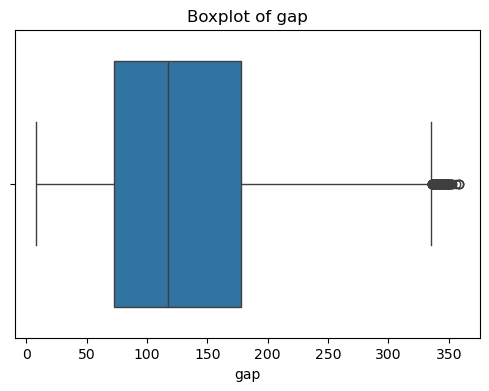

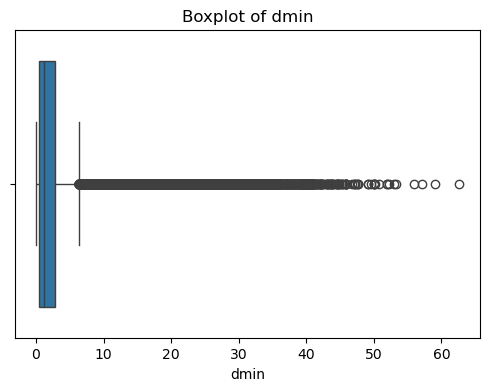

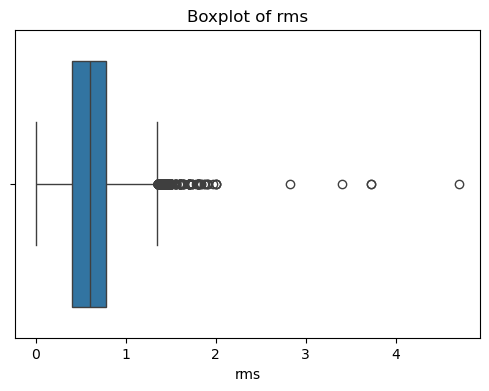

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

cols = ['mag', 'depth_km', 'nst', 'gap', 'dmin', 'rms']

for col in cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

### Quantification des valeurs aberrantes

Nous calculons le pourcentage d'outliers pour chaque variable numérique afin d’évaluer leur impact potentiel.

In [16]:
def outlier_percentage(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    percent = (len(outliers) / len(df)) * 100
    return percent

In [17]:
cols = ['mag', 'depth_km', 'nst', 'gap', 'dmin', 'rms']

for col in cols:
    print(col, ":", round(outlier_percentage(df, col), 2), "% outliers")

mag : 0.08 % outliers
depth_km : 11.8 % outliers
nst : 5.83 % outliers
gap : 0.13 % outliers
dmin : 8.47 % outliers
rms : 0.32 % outliers


In [18]:
cols = ['mag', 'depth_km', 'nst', 'gap', 'dmin', 'rms','sig','latitude','longitude']

for col in cols:
    min_val = df[col].min()
    max_val = df[col].max()

    print(f"{col} :")
    print(f"  Valeur minimale = {min_val:.2f}")
    print(f"  Valeur maximale = {max_val:.2f}\n")

mag :
  Valeur minimale = 2.50
  Valeur maximale = 8.80

depth_km :
  Valeur minimale = -3.74
  Valeur maximale = 681.24

nst :
  Valeur minimale = 0.00
  Valeur maximale = 619.00

gap :
  Valeur minimale = 8.00
  Valeur maximale = 358.18

dmin :
  Valeur minimale = 0.00
  Valeur maximale = 62.56

rms :
  Valeur minimale = 0.00
  Valeur maximale = 4.70

sig :
  Valeur minimale = 96.00
  Valeur maximale = 2910.00

latitude :
  Valeur minimale = -84.49
  Valeur maximale = 87.08

longitude :
  Valeur minimale = -180.00
  Valeur maximale = 180.00



## 7️⃣ Nettoyage des valeurs aberrantes

Les observations ne respectant pas les seuils physiques ou métier sont supprimées afin d'améliorer la qualité des données.

In [19]:
def detect_outliers(df):

    rules = {
        "depth_km": (0, 700),
        "nst": (3, 1000),
        "gap": (0, 360),
        "dmin": (0, 100),
        "rms": (0, 10),
        "sig": (0, 5000),
        "mag" : (2, 9)
    }

    print("\n🔥 OUTLIERS PERCENTAGE REPORT\n")
    print("=" * 40)

    total_rows = len(df)

    for col, (low, high) in rules.items():

        if col in df.columns:

            outliers = df[(df[col] < low) | (df[col] > high)]

            percent = (len(outliers) / total_rows) * 100

            print(f"\n📌 {col}")
            print(f"➡️ Allowed range: [{low} , {high}]")
            print(f"❌ Outliers: {len(outliers)}")
            print(f"📊 Percentage: {percent:.2f}%")

    print("\n" + "=" * 40)
    print("✅ Done")

In [20]:
detect_outliers(df)


🔥 OUTLIERS PERCENTAGE REPORT


📌 depth_km
➡️ Allowed range: [0 , 700]
❌ Outliers: 390
📊 Percentage: 0.29%

📌 nst
➡️ Allowed range: [3 , 1000]
❌ Outliers: 7
📊 Percentage: 0.01%

📌 gap
➡️ Allowed range: [0 , 360]
❌ Outliers: 0
📊 Percentage: 0.00%

📌 dmin
➡️ Allowed range: [0 , 100]
❌ Outliers: 0
📊 Percentage: 0.00%

📌 rms
➡️ Allowed range: [0 , 10]
❌ Outliers: 0
📊 Percentage: 0.00%

📌 sig
➡️ Allowed range: [0 , 5000]
❌ Outliers: 0
📊 Percentage: 0.00%

📌 mag
➡️ Allowed range: [2 , 9]
❌ Outliers: 0
📊 Percentage: 0.00%

✅ Done


In [21]:
def remove_outliers(df):

    conditions = (
        (df["depth_km"] >= 0) & (df["depth_km"] <= 700) &
        (df["nst"] >= 3) & (df["nst"] <= 1000) &
        (df["gap"] >= 0) & (df["gap"] <= 360) &
        (df["dmin"] >= 0) & (df["dmin"] <= 100) &
        (df["rms"] >= 0) & (df["rms"] <= 10) &
        (df["sig"] >= 0) & (df["sig"] <= 5000) &
        (df["mag"] >= 2) & (df["mag"] <= 9)
    )

    df_clean = df[conditions].copy()

    return df_clean

In [22]:
df = remove_outliers(df)
print(df.shape)

(136060, 23)


In [23]:
def drop_unnecessary_columns(df):
    cols_to_drop = ["id", "updated_utc", "url"]
    
    df_clean = df.drop(columns=cols_to_drop, errors="ignore").copy()
    
    return df_clean

In [24]:
df = drop_unnecessary_columns(df)
print(df.columns)

Index(['time_utc', 'longitude', 'latitude', 'depth_km', 'place', 'mag',
       'magType', 'nst', 'gap', 'dmin', 'rms', 'net', 'tsunami', 'sig',
       'status', 'type', 'year', 'month', 'day', 'hour'],
      dtype='object')


## 9️⃣ Transformation des variables numériques

Certaines variables présentent une forte asymétrie.

Une transformation logarithmique est appliquée afin de réduire cette asymétrie et faciliter l'apprentissage des modèles.

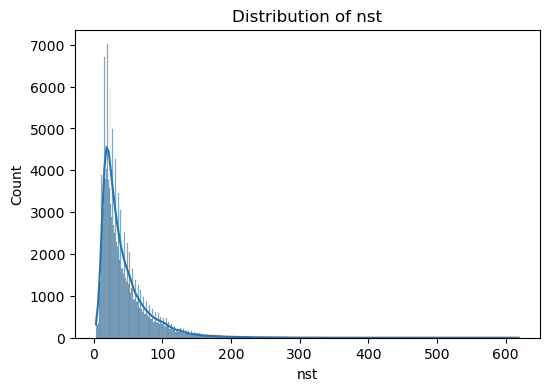

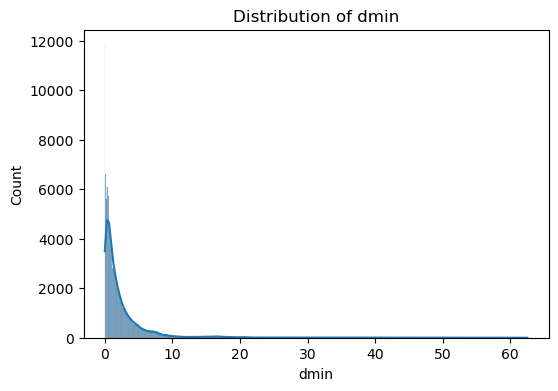

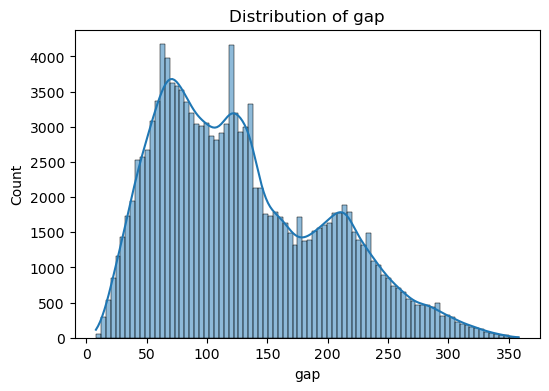

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

cols = ['nst', 'dmin', 'gap']

for col in cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

In [26]:
import numpy as np

df["depth_km_log"] = np.log1p(df["depth_km"])
df["nst_log"] = np.log1p(df["nst"])
df["dmin_log"] = np.log1p(df["dmin"])
df["sig_log"] = np.log1p(df["sig"])

### Vérification des distributions après transformation logarithmique

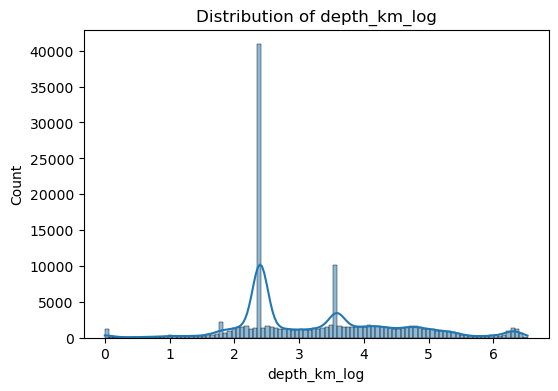

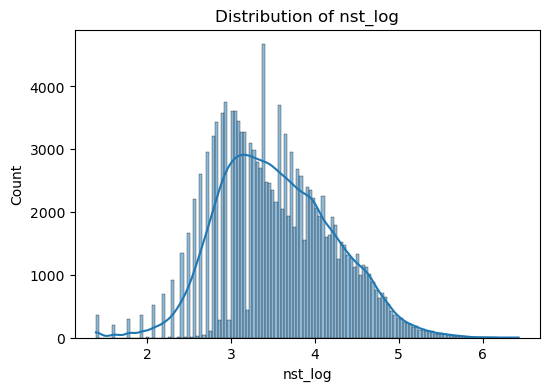

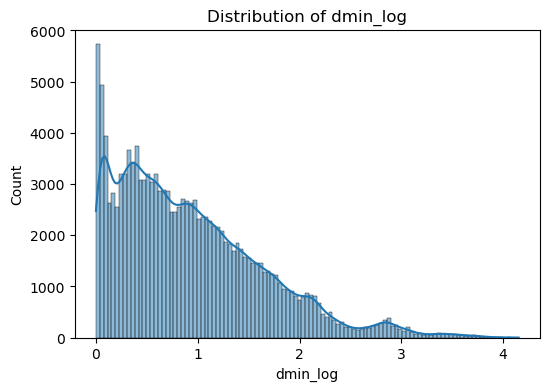

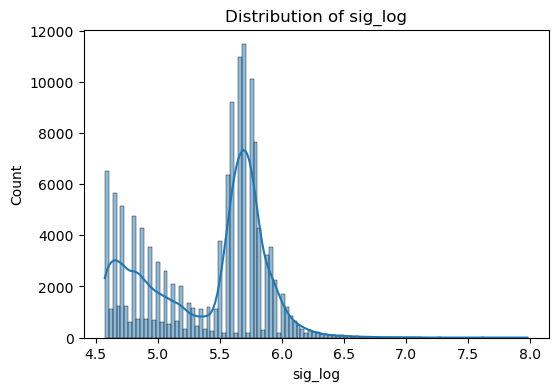

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

cols = ['depth_km_log', 'nst_log', 'dmin_log', 'sig_log']

for col in cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

In [28]:
import matplotlib.pyplot as plt

def plot_categorical_eda(df, column):

    # حساب النسب
    counts = df[column].value_counts()
    percentages = df[column].value_counts(normalize=True) * 100

    # طباعة النتائج
    print(f"\n📊 {column}")
    for val in counts.index:
        print(f"{val} : {counts[val]} ({percentages[val]:.2f}%)")

    # رسم diagramme
    plt.figure()
    counts.plot(kind="bar")

    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Count")

    plt.show()

## 🔟 Analyse des variables catégorielles

Nous étudions la distribution des variables catégorielles afin d’identifier les catégories dominantes et les éventuels déséquilibres.


📊 status
reviewed : 135090 (99.29%)
automatic : 970 (0.71%)


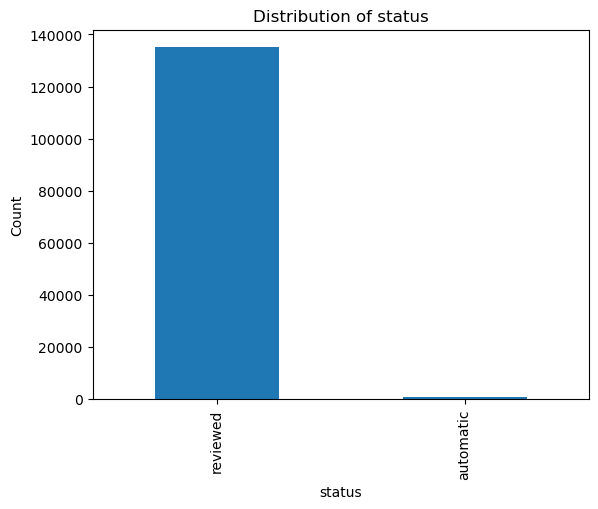

In [29]:
plot_categorical_eda(df, "status")



📊 type
earthquake : 134896 (99.14%)
mining explosion : 1013 (0.74%)
ice quake : 108 (0.08%)
other event : 12 (0.01%)
volcanic eruption : 11 (0.01%)
explosion : 8 (0.01%)
quarry blast : 3 (0.00%)
mine collapse : 3 (0.00%)
experimental explosion : 3 (0.00%)
Landslide : 2 (0.00%)
landslide : 1 (0.00%)


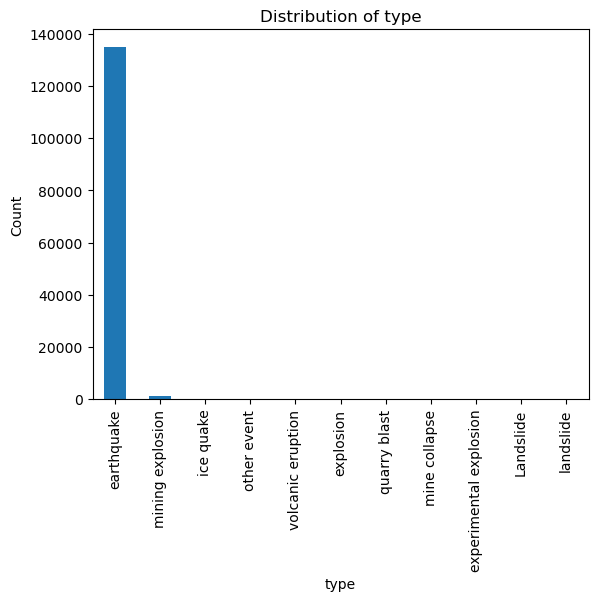

In [30]:
plot_categorical_eda(df, "type")

### Sélection des événements sismiques validés

Afin de garantir la qualité des données, seules les observations correspondant à de véritables séismes validés par les experts sont conservées.

In [31]:
df = df[df["type"] == "earthquake"]

In [32]:
df = df[df["status"] == "reviewed"]

In [33]:
df = df.drop(columns=["type", "status"])

In [34]:
print(df.columns)

Index(['time_utc', 'longitude', 'latitude', 'depth_km', 'place', 'mag',
       'magType', 'nst', 'gap', 'dmin', 'rms', 'net', 'tsunami', 'sig', 'year',
       'month', 'day', 'hour', 'depth_km_log', 'nst_log', 'dmin_log',
       'sig_log'],
      dtype='object')


## 1️⃣1️⃣ Feature Engineering

Cette étape consiste à créer de nouvelles variables à partir des informations existantes afin d’enrichir les données et améliorer les performances des modèles.

In [35]:
# ─────────────────────────────────────────────
# B1 : VARIABLES TEMPORELLES
# ─────────────────────────────────────────────

df['year']       = df['time_utc'].dt.year
df['month']      = df['time_utc'].dt.month           # 1-12
df['week']       = df['time_utc'].dt.isocalendar().week.astype(int)  # 1-53
df['day']        = df['time_utc'].dt.day             # 1-31
df['hour']       = df['time_utc'].dt.hour            # 0-23
df['dayofweek']  = df['time_utc'].dt.dayofweek       # 0=Lundi, 6=Dimanche
df['quarter']    = df['time_utc'].dt.quarter         # 1-4
df['yearweek']   = df['time_utc'].dt.to_period('W').astype(str)  # '2023-W12' pour LSTM

# Noms lisibles pour visualisation
MOIS_FR = {1:'Jan',2:'Fév',3:'Mar',4:'Avr',5:'Mai',6:'Jun',
           7:'Jul',8:'Aoû',9:'Sep',10:'Oct',11:'Nov',12:'Déc'}
JOURS_FR = {0:'Lun',1:'Mar',2:'Mer',3:'Jeu',4:'Ven',5:'Sam',6:'Dim'}

df['month_name'] = df['month'].map(MOIS_FR)
df['day_name']   = df['dayofweek'].map(JOURS_FR)

print('Variables temporelles créées :')
print(df[['time_utc','year','month','week','day','hour','dayofweek','quarter','yearweek']].head(5).to_string())
print(f'\nNombre de semaines uniques : {df.yearweek.nunique()}')

Variables temporelles créées :
             time_utc  year  month  week  day  hour  dayofweek  quarter               yearweek
0 2026-05-05 23:10:51  2026      5    19    5    23          1        2  2026-05-04/2026-05-10
1 2026-05-05 23:02:33  2026      5    19    5    23          1        2  2026-05-04/2026-05-10
2 2026-05-05 22:57:40  2026      5    19    5    22          1        2  2026-05-04/2026-05-10
5 2026-05-05 22:02:01  2026      5    19    5    22          1        2  2026-05-04/2026-05-10
6 2026-05-05 21:37:25  2026      5    19    5    21          1        2  2026-05-04/2026-05-10

Nombre de semaines uniques : 262


### Création de la variable géographique "Region"

À partir du champ textuel "place" et des coordonnées GPS, nous construisons une variable représentant la grande région sismique associée à chaque événement.

In [36]:
# ─────────────────────────────────────────────
# B2 AMÉLIORÉ : EXTRACTION RÉGION — VERSION ROBUSTE
# ─────────────────────────────────────────────
import re

# ── ÉTAPE 1 : Extraire le suffixe après la dernière virgule ──────────────
# Format USGS : "117 km E of Chignik, Alaska"  →  "Alaska"
#               "18 km W of Sarabetsu, Japan"  →  "Japan"
#               "Hokkaido, Japan"               →  "Japan"

def get_suffix(place_str):
    """Retourne la partie après la dernière virgule, nettoyée."""
    if pd.isna(place_str):
        return ''
    parts = str(place_str).split(',')
    return parts[-1].strip().lower()

# ── ÉTAPE 2 : Dictionnaire de mapping suffix → grande zone ──────────────
# Clé = mot(s) qui apparaissent dans le suffixe USGS
# On mappe vers des noms de zones cohérents pour le clustering

SUFFIX_MAP = {
    # ─── USA ───────────────────────────────────────────────────────────
    'alaska'           : 'Alaska',
    'california'       : 'California',
    'hawaii'           : 'Hawaii',
    'nevada'           : 'Nevada-Utah',
    'utah'             : 'Nevada-Utah',
    'washington'       : 'Pacific Northwest',
    'oregon'           : 'Pacific Northwest',
    'montana'          : 'Rocky Mountains',
    'wyoming'          : 'Rocky Mountains',
    'idaho'            : 'Rocky Mountains',
    'oklahoma'         : 'Central USA',
    'kansas'           : 'Central USA',
    'tennessee'        : 'Eastern USA',
    'south carolina'   : 'Eastern USA',
    'puerto rico'      : 'Caribbean',
    'virgin islands'   : 'Caribbean',
    'guam'             : 'Mariana Islands',
    'northern mariana islands': 'Mariana Islands',
    # ─── Amériques ─────────────────────────────────────────────────────
    'chile'            : 'Chile',
    'peru'             : 'Peru',
    'mexico'           : 'Mexico',
    'ecuador'          : 'Ecuador',
    'colombia'         : 'Colombia',
    'bolivia'          : 'Bolivia-Argentina',
    'argentina'        : 'Bolivia-Argentina',
    'panama'           : 'Central America',
    'costa rica'       : 'Central America',
    'nicaragua'        : 'Central America',
    'guatemala'        : 'Central America',
    'el salvador'      : 'Central America',
    'honduras'         : 'Central America',
    'haiti'            : 'Caribbean',
    'dominican republic': 'Caribbean',
    'cuba'             : 'Caribbean',
    'trinidad'         : 'Caribbean',
    'venezuela'        : 'Caribbean',
    'canada'           : 'Canada',
    'brazil'           : 'Brazil',
    # ─── Asie-Pacifique ────────────────────────────────────────────────
    'japan'            : 'Japan',
    'indonesia'        : 'Indonesia',
    'philippines'      : 'Philippines',
    'papua new guinea' : 'Papua New Guinea',
    'new zealand'      : 'New Zealand',
    'tonga'            : 'Tonga-Samoa',
    'samoa'            : 'Tonga-Samoa',
    'american samoa'   : 'Tonga-Samoa',
    'fiji'             : 'Tonga-Samoa',
    'vanuatu'          : 'Tonga-Samoa',
    'solomon islands'  : 'Papua New Guinea',
    'russia'           : 'Russia-Kamchatka',
    'china'            : 'China',
    'taiwan'           : 'Taiwan',
    'myanmar'          : 'Myanmar-SE Asia',
    'vietnam'          : 'Myanmar-SE Asia',
    'thailand'         : 'Myanmar-SE Asia',
    'india'            : 'India',
    'nepal'            : 'India',
    'pakistan'         : 'Afghanistan-Pakistan',
    'afghanistan'      : 'Afghanistan-Pakistan',
    'iran'             : 'Iran',
    'iraq'             : 'Middle East',
    'saudi arabia'     : 'Middle East',
    'yemen'            : 'Middle East',
    'tajikistan'       : 'Central Asia',
    'kyrgyzstan'       : 'Central Asia',
    'kazakhstan'       : 'Central Asia',
    'uzbekistan'       : 'Central Asia',
    'mongolia'         : 'Central Asia',
    # ─── Europe / Méditerranée ─────────────────────────────────────────
    'turkey'           : 'Turkey',
    'greece'           : 'Greece',
    'italy'            : 'Italy',
    'spain'            : 'Iberian Peninsula',
    'portugal'         : 'Iberian Peninsula',
    'romania'          : 'Romania',
    'croatia'          : 'Balkans',
    'albania'          : 'Balkans',
    'serbia'           : 'Balkans',
    'north macedonia'  : 'Balkans',
    'bosnia and herzegovina': 'Balkans',
    'kosovo'           : 'Balkans',
    'georgia'          : 'Caucasus',
    'armenia'          : 'Caucasus',
    'azerbaijan'       : 'Caucasus',
    'iceland'          : 'Atlantic Ridge',
    'azores'           : 'Atlantic Ridge',
    'canary islands'   : 'Atlantic Ridge',
    # ─── Afrique ───────────────────────────────────────────────────────
    'kenya'            : 'East Africa',
    'ethiopia'         : 'East Africa',
    'tanzania'         : 'East Africa',
    'mozambique'       : 'East Africa',
    'malawi'           : 'East Africa',
    'rwanda'           : 'East Africa',
    'uganda'           : 'East Africa',
    'democratic republic of the congo': 'East Africa',
    'eritrea'          : 'East Africa',
    'morocco'          : 'North Africa',
    'algeria'          : 'North Africa',
    'libya'            : 'North Africa',
    'egypt'            : 'North Africa',
    'tunisia'          : 'North Africa',
    # ─── Océans ────────────────────────────────────────────────────────
    'south georgia and the south sandwich islands': 'Antarctic',
    'french polynesia' : 'Pacific Ocean',
    'new caledonia'    : 'Pacific Ocean',
    'marshall islands' : 'Pacific Ocean',
}

# ── ÉTAPE 3 : Fallback GPS → continent/ocean ────────────────────────────
def gps_to_zone(lat, lon):
    """Classe par coordonnées si le texte ne suffit pas."""
    if pd.isna(lat) or pd.isna(lon):
        return 'Unknown'
    lat, lon = float(lat), float(lon)

    # Zones océaniques
    if lat < -60:
        return 'Antarctic'
    if lat > 66:
        return 'Arctic'

    # Grands bassins
    if -90 <= lon <= -30 and lat > 0:
        return 'North Atlantic'
    if -90 <= lon <= -30 and lat <= 0:
        return 'South Atlantic'
    if 30 <= lon <= 100 and -10 <= lat <= 30:
        return 'Indian Ocean'
    if (lon > 140 or lon < -60) and lat > 0:
        return 'North Pacific'
    if (lon > 140 or lon < -60) and lat <= 0:
        return 'South Pacific'
    if -30 <= lon <= 30 and -35 <= lat <= 37:
        return 'Atlantic Ridge'

    return 'Other'

# ── FONCTION PRINCIPALE ──────────────────────────────────────────────────
def extract_region_v2(row):
    """
    Pipeline complet :
    1. Extraire suffixe après virgule
    2. Chercher dans SUFFIX_MAP (correspondance exacte)
    3. Chercher par sous-chaîne dans SUFFIX_MAP (partielle)
    4. Fallback GPS
    """
    place = row.get('place', '') if isinstance(row, dict) else row['place']
    lat   = row.get('latitude', None) if isinstance(row, dict) else row['latitude']
    lon   = row.get('longitude', None) if isinstance(row, dict) else row['longitude']

    suffix = get_suffix(place)

    # Correspondance exacte
    if suffix in SUFFIX_MAP:
        return SUFFIX_MAP[suffix]

    # Correspondance partielle (ex: "hokkaido, japan" → suffix = "japan")
    for key, zone in SUFFIX_MAP.items():
        if key in suffix:
            return zone

    # Fallback GPS
    return gps_to_zone(lat, lon)


# ── APPLICATION ──────────────────────────────────────────────────────────
df['region'] = df.apply(extract_region_v2, axis=1)

# ── DIAGNOSTIC ───────────────────────────────────────────────────────────
total = len(df)
region_counts = df['region'].value_counts()

print('Distribution des régions (Top 25) :')
print(region_counts.head(25).to_string())

n_unknown = df['region'].isin(['Unknown', 'Other']).sum()
n_gps     = df['region'].isin(['North Atlantic', 'South Atlantic',
                                'Indian Ocean', 'North Pacific',
                                'South Pacific', 'Antarctic', 'Arctic']).sum()
n_named   = total - n_unknown - n_gps

print(f'\nRégions nommées  (via texte) : {n_named:,}  ({n_named/total*100:.1f}%)')
print(f'Régions océan    (via GPS)   : {n_gps:,}  ({n_gps/total*100:.1f}%)')
print(f'Unknown/Other    (non classé): {n_unknown:,}  ({n_unknown/total*100:.1f}%)')
print(f'\nNombre de zones uniques      : {df.region.nunique()}')

Distribution des régions (Top 25) :
region
Alaska                  29138
Tonga-Samoa              9611
Caribbean                9540
North Pacific            8596
Indonesia                8059
Japan                    6431
Russia-Kamchatka         6019
Other                    5469
Philippines              4396
Papua New Guinea         4367
South Pacific            3799
Chile                    3110
Mexico                   2997
Hawaii                   2945
India                    2213
Mariana Islands          2029
North Atlantic           1871
Central America          1668
Bolivia-Argentina        1606
Greece                   1301
China                    1290
Peru                     1276
New Zealand              1273
Afghanistan-Pakistan     1174
Nevada-Utah              1130

Régions nommées  (via texte) : 112,338  (83.9%)
Régions océan    (via GPS)   : 16,122  (12.0%)
Unknown/Other    (non classé): 5,469  (4.1%)

Nombre de zones uniques      : 53


In [37]:
df = df[~df["region"].isin(["Unknown", "Other"])]

In [38]:
df.shape

(128460, 29)

### Construction de la variable cible

La magnitude est transformée en classes représentant différents niveaux de risque sismique :

- Faible
- Modéré
- Fort
- Majeur

Cette variable constituera la cible de notre modèle de classification.

In [39]:
# ─────────────────────────────────────────────
# B4 : VARIABLE mag_class
# ─────────────────────────────────────────────

def classify_magnitude(mag):
    """Classification standard Richter adaptée."""
    if mag < 4.0:
        return 'Faible'      # Ressenti peu ou pas
    elif mag < 5.5:
        return 'Modéré'      # Dommages légers possibles
    elif mag < 7.0:
        return 'Fort'        # Dommages importants
    else:
        return 'Majeur'      # Catastrophique

df['mag_class'] = df['mag'].apply(classify_magnitude)

# Ordre catégoriel logique
ordre = ['Faible', 'Modéré', 'Fort', 'Majeur']
df['mag_class'] = pd.Categorical(df['mag_class'], categories=ordre, ordered=True)

# Aussi créer une version numérique pour les modèles ML
mapping_num = {'Faible': 0, 'Modéré': 1, 'Fort': 2, 'Majeur': 3}
df['mag_class_num'] = df['mag_class'].map(mapping_num)

print('Distribution mag_class :')
dist = df['mag_class'].value_counts().reindex(ordre)
for cls, count in dist.items():
    pct = count / len(df) * 100
    bar = '█' * int(pct / 2)
    print(f'  {cls:8s} : {count:7,} ({pct:5.1f}%)  {bar}')

Distribution mag_class :
  Faible   :  53,396 ( 41.6%)  ████████████████████
  Modéré   :  72,939 ( 56.8%)  ████████████████████████████
  Fort     :   2,060 (  1.6%)  
  Majeur   :      65 (  0.1%)  


In [40]:
df.columns

Index(['time_utc', 'longitude', 'latitude', 'depth_km', 'place', 'mag',
       'magType', 'nst', 'gap', 'dmin', 'rms', 'net', 'tsunami', 'sig', 'year',
       'month', 'day', 'hour', 'depth_km_log', 'nst_log', 'dmin_log',
       'sig_log', 'week', 'dayofweek', 'quarter', 'yearweek', 'month_name',
       'day_name', 'region', 'mag_class', 'mag_class_num'],
      dtype='object')

# 📊 Analyse Exploratoire des Données (EDA)

L’objectif de cette phase est d’explorer les données afin de comprendre les relations entre les variables, identifier les tendances et mettre en évidence les facteurs influençant la gravité des séismes.

# EDA

In [41]:
# Setup visualisation — À exécuter UNE FOIS avant tous les graphiques
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

# Palette couleurs par magnitude
PALETTE_MAG = {
    'Faible' : '#2196F3',  # Bleu
    'Modéré' : '#FF9800',  # Orange
    'Fort'   : '#F44336',  # Rouge
    'Majeur' : '#9C27B0',  # Violet
}
print('Setup visualisation OK')

Setup visualisation OK


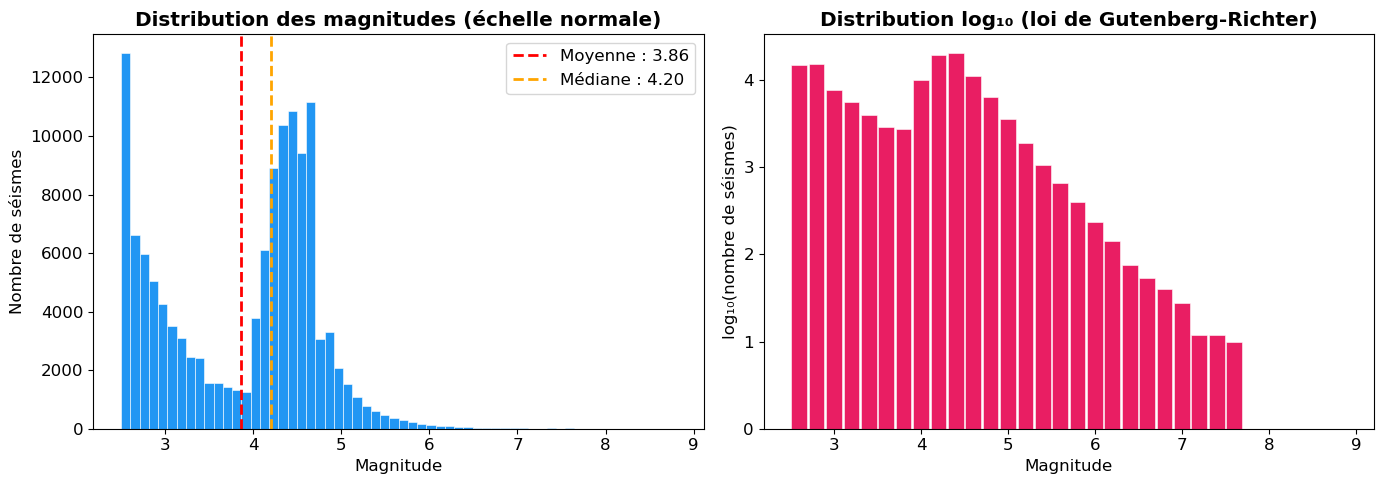

Observation : Relation linéaire en échelle log → loi de Gutenberg-Richter confirmée.
  Séismes Faibles (<4.0)  : 53,396 (41.6%)
  Séismes Modérés (4-5.5) : 73,397 (57.1%)
  Séismes Forts (5.5-7.0) : 2,078 (1.6%)
  Séismes Majeurs (>7.0)  : 65 (0.1%)


In [42]:
# C2 : DISTRIBUTION MAGNITUDE
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramme normal
axes[0].hist(df['mag'], bins=60, color='#2196F3', edgecolor='white', linewidth=0.4)
axes[0].axvline(df['mag'].mean(), color='red', linestyle='--', linewidth=2, label=f"Moyenne : {df['mag'].mean():.2f}")
axes[0].axvline(df['mag'].median(), color='orange', linestyle='--', linewidth=2, label=f"Médiane : {df['mag'].median():.2f}")
axes[0].set_title('Distribution des magnitudes (échelle normale)', fontweight='bold')
axes[0].set_xlabel('Magnitude'); axes[0].set_ylabel('Nombre de séismes')
axes[0].legend()

# Histogramme log (loi de Gutenberg-Richter)
bins = np.arange(2.5, 9.5, 0.2)
counts, edges = np.histogram(df['mag'], bins=bins)
centers = (edges[:-1] + edges[1:]) / 2
mask_pos = counts > 0
axes[1].bar(centers[mask_pos], np.log10(counts[mask_pos]), width=0.18,
            color='#E91E63', edgecolor='white', linewidth=0.4)
axes[1].set_title('Distribution log₁₀ (loi de Gutenberg-Richter)', fontweight='bold')
axes[1].set_xlabel('Magnitude'); axes[1].set_ylabel('log₁₀(nombre de séismes)')

plt.tight_layout()
plt.savefig('C2_distribution_magnitude.png', dpi=150, bbox_inches='tight')
plt.show()

print('Observation : Relation linéaire en échelle log → loi de Gutenberg-Richter confirmée.')
print(f'  Séismes Faibles (<4.0)  : {(df.mag < 4.0).sum():,} ({(df.mag < 4.0).mean()*100:.1f}%)')
print(f'  Séismes Modérés (4-5.5) : {df.mag.between(4.0,5.5).sum():,} ({df.mag.between(4.0,5.5).mean()*100:.1f}%)')
print(f'  Séismes Forts (5.5-7.0) : {df.mag.between(5.5,7.0).sum():,} ({df.mag.between(5.5,7.0).mean()*100:.1f}%)')
print(f'  Séismes Majeurs (>7.0)  : {(df.mag >= 7.0).sum():,} ({(df.mag >= 7.0).mean()*100:.1f}%)')

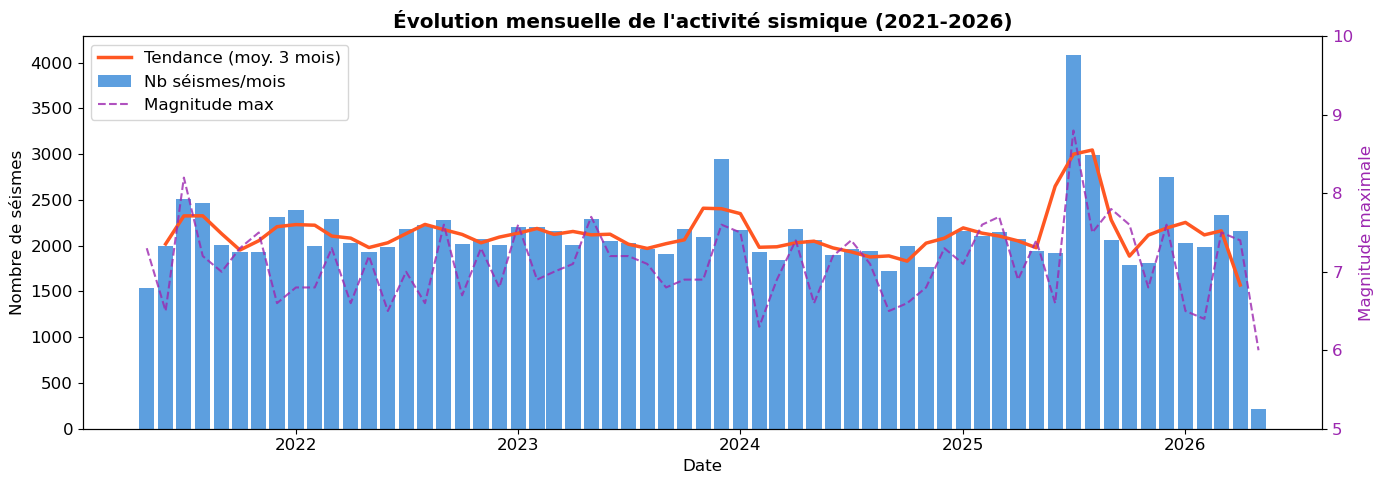

Mois le plus actif : July 2025 (4,082 séismes)


In [43]:
# C3 : EVOLUTION MENSUELLE
df_monthly = df.groupby(['year', 'month']).agg(
    nb_seismes = ('mag', 'count'),
    mag_mean   = ('mag', 'mean'),
    mag_max    = ('mag', 'max'),
).reset_index()
df_monthly['date'] = pd.to_datetime(df_monthly[['year','month']].assign(day=1))
df_monthly = df_monthly.sort_values('date')

fig, ax1 = plt.subplots(figsize=(14, 5))

# Barres = nombre de séismes
ax1.bar(df_monthly['date'], df_monthly['nb_seismes'],
        width=25, color='#1976D2', alpha=0.7, label='Nb séismes/mois')

# Ligne de tendance (moyenne mobile 3 mois)
df_monthly['rolling'] = df_monthly['nb_seismes'].rolling(3, center=True).mean()
ax1.plot(df_monthly['date'], df_monthly['rolling'],
         color='#FF5722', linewidth=2.5, label='Tendance (moy. 3 mois)')

# Axe secondaire = magnitude max
ax2 = ax1.twinx()
ax2.plot(df_monthly['date'], df_monthly['mag_max'],
         color='#9C27B0', linewidth=1.5, linestyle='--', alpha=0.8, label='Magnitude max')
ax2.set_ylabel('Magnitude maximale', color='#9C27B0')
ax2.tick_params(axis='y', labelcolor='#9C27B0')
ax2.set_ylim([5, 10])

ax1.set_title('Évolution mensuelle de l\'activité sismique (2021-2026)', fontweight='bold')
ax1.set_xlabel('Date'); ax1.set_ylabel('Nombre de séismes')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig('C3_evolution_mensuelle.png', dpi=150, bbox_inches='tight')
plt.show()

mois_actif = df_monthly.loc[df_monthly.nb_seismes.idxmax()]
print(f'Mois le plus actif : {mois_actif.date.strftime("%B %Y")} ({int(mois_actif.nb_seismes):,} séismes)')

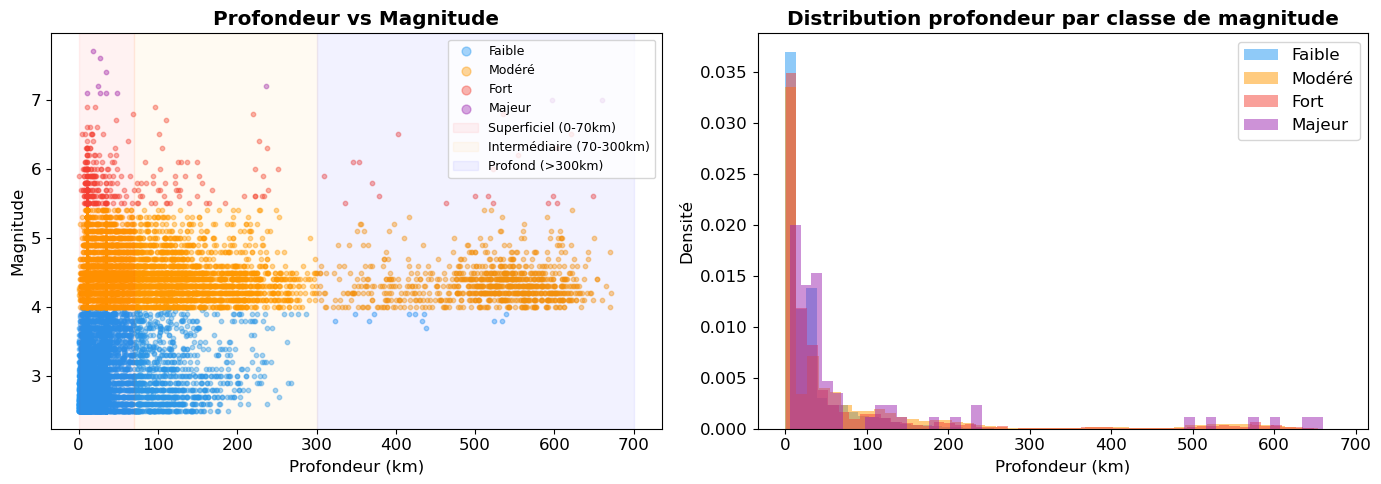

Séismes superficiels (0-70km)    : 100549 (78.3%)
Séismes intermédiaires (70-300km): 22027
Séismes profonds (>300km)        : 5884


In [44]:
# C4 : DEPTH vs MAGNITUDE
df_sample = df.sample(n=20000, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter coloré par classe
colors_map = {'Faible':'#2196F3','Modéré':'#FF9800','Fort':'#F44336','Majeur':'#9C27B0'}
for cls in ['Faible', 'Modéré', 'Fort', 'Majeur']:
    mask = df_sample['mag_class'] == cls
    axes[0].scatter(
        df_sample.loc[mask, 'depth_km'],
        df_sample.loc[mask, 'mag'],
        c=colors_map[cls], alpha=0.4, s=10, label=cls
    )

# Zones de profondeur
axes[0].axvspan(0,   70,  alpha=0.05, color='red',   label='Superficiel (0-70km)')
axes[0].axvspan(70,  300, alpha=0.05, color='orange', label='Intermédiaire (70-300km)')
axes[0].axvspan(300, 700, alpha=0.05, color='blue',   label='Profond (>300km)')
axes[0].set_xlabel('Profondeur (km)'); axes[0].set_ylabel('Magnitude')
axes[0].set_title('Profondeur vs Magnitude', fontweight='bold')
axes[0].legend(fontsize=9, markerscale=2)

# Distribution des profondeurs par classe
for cls in ['Faible', 'Modéré', 'Fort', 'Majeur']:
    mask = df['mag_class'] == cls
    axes[1].hist(df.loc[mask, 'depth_km'], bins=50, alpha=0.5,
                 color=colors_map[cls], label=cls, density=True)
axes[1].set_xlabel('Profondeur (km)'); axes[1].set_ylabel('Densité')
axes[1].set_title('Distribution profondeur par classe de magnitude', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('C4_depth_vs_magnitude.png', dpi=150, bbox_inches='tight')
plt.show()

print('Séismes superficiels (0-70km)    :', df['depth_km'].lt(70).sum(), f"({df['depth_km'].lt(70).mean()*100:.1f}%)")
print('Séismes intermédiaires (70-300km):', df['depth_km'].between(70,300).sum())
print('Séismes profonds (>300km)        :', df['depth_km'].gt(300).sum())

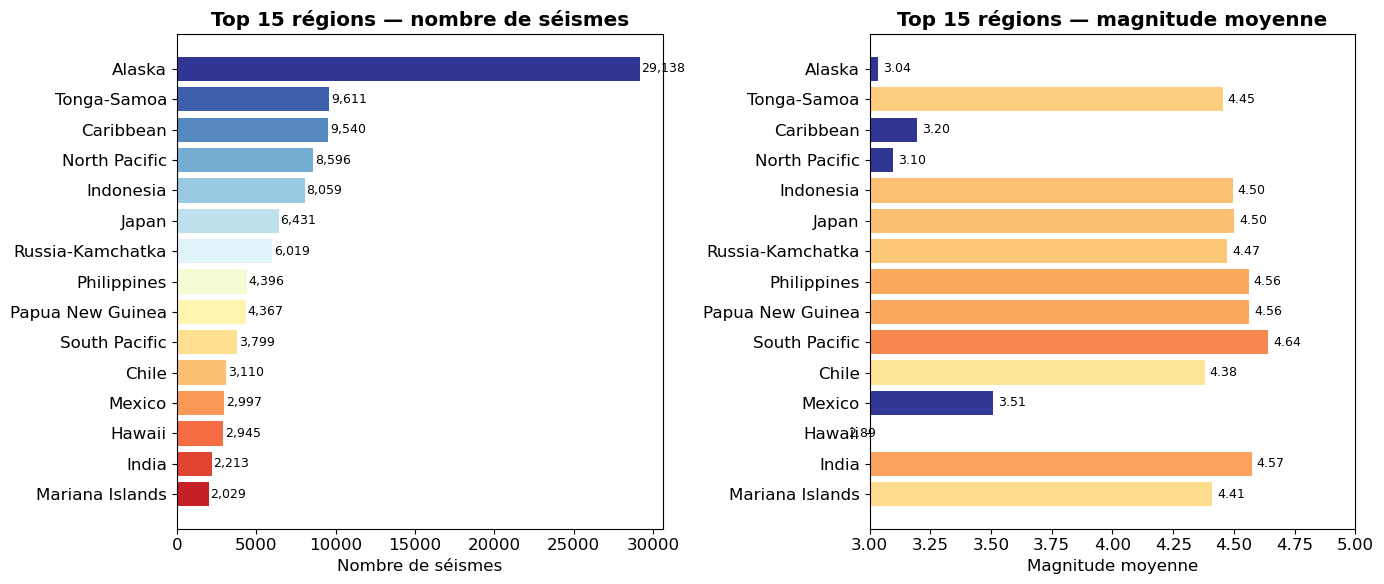

Region #1 : Alaska → 29138 séismes


In [45]:
# C5 : TOP 15 REGIONS
top_regions = df['region'].value_counts().head(15)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Barplot horizontal — nb séismes
cmap = plt.cm.RdYlBu_r
colors = [cmap(i/15) for i in range(14, -1, -1)]

bars = axes[0].barh(top_regions.index[::-1], top_regions.values[::-1], color=colors)
axes[0].set_title('Top 15 régions — nombre de séismes', fontweight='bold')
axes[0].set_xlabel('Nombre de séismes')
for bar, val in zip(bars, top_regions.values[::-1]):
    axes[0].text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
                 f'{val:,}', va='center', fontsize=9)

# Magnitude moyenne par région (top 15)
mag_par_region = df[df['region'].isin(top_regions.index)].groupby('region')['mag'].mean()
mag_par_region = mag_par_region.reindex(top_regions.index)
colors_mag = [cmap((m - 3.5) / 1.5) for m in mag_par_region.values]

bars2 = axes[1].barh(mag_par_region.index[::-1], mag_par_region.values[::-1], color=colors_mag[::-1])
axes[1].set_title('Top 15 régions — magnitude moyenne', fontweight='bold')
axes[1].set_xlabel('Magnitude moyenne')
axes[1].set_xlim([3.0, 5.0])
for bar, val in zip(bars2, mag_par_region.values[::-1]):
    axes[1].text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
                 f'{val:.2f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('C5_top_regions.png', dpi=150, bbox_inches='tight')
plt.show()

print('Region #1 :', top_regions.index[0], '→', top_regions.iloc[0], 'séismes')

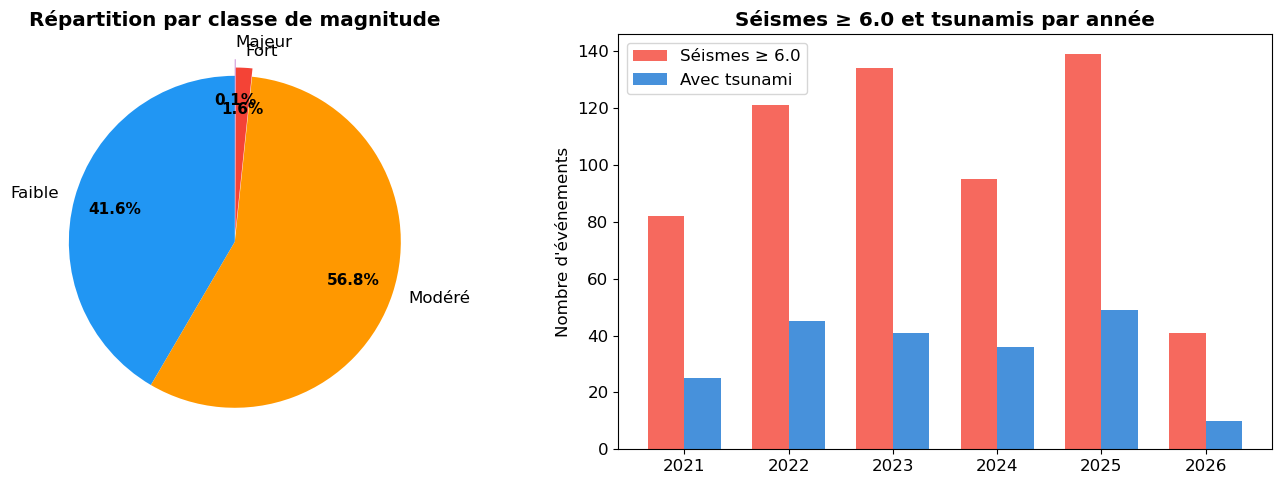

Séismes ≥ 6.0  : 612 (0.48%)
Avec tsunami   : 610 (0.47%)
Magnitude max  : 8.8


In [46]:
# C8 : SEISMES MAJEURS + TSUNAMIS
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart classe magnitude
dist_class = df['mag_class'].value_counts().reindex(['Faible','Modéré','Fort','Majeur'])
colors_pie = ['#2196F3', '#FF9800', '#F44336', '#9C27B0']
wedges, texts, autotexts = axes[0].pie(
    dist_class.values,
    labels=dist_class.index,
    autopct='%1.1f%%',
    colors=colors_pie,
    startangle=90,
    pctdistance=0.75,
    explode=[0, 0, 0.05, 0.1]
)
for at in autotexts:
    at.set_fontsize(11); at.set_fontweight('bold')
axes[0].set_title('Répartition par classe de magnitude', fontweight='bold')

# Évolution annuelle séismes forts + tsunamis
df_danger = df[df['mag'] >= 6.0].groupby('year').agg(
    nb_forts   = ('mag', 'count'),
    nb_tsunami = ('tsunami', 'sum')
).reset_index()

x = np.arange(len(df_danger))
w = 0.35
axes[1].bar(x - w/2, df_danger['nb_forts'],   w, label='Séismes ≥ 6.0', color='#F44336', alpha=0.8)
axes[1].bar(x + w/2, df_danger['nb_tsunami'],  w, label='Avec tsunami',  color='#1976D2', alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(df_danger['year'].astype(str))
axes[1].set_title('Séismes ≥ 6.0 et tsunamis par année', fontweight='bold')
axes[1].set_ylabel('Nombre d\'événements')
axes[1].legend()

plt.tight_layout()
plt.savefig('C8_majeurs_tsunamis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Séismes ≥ 6.0  : {(df.mag >= 6.0).sum():,} ({(df.mag >= 6.0).mean()*100:.2f}%)')
print(f'Avec tsunami   : {int(df.tsunami.sum()):,} ({df.tsunami.mean()*100:.2f}%)')
print(f'Magnitude max  : {df.mag.max()}')

In [47]:
# ══════════════════════════════════════════════
# PARTIE 3 — EDA
# ══════════════════════════════════════════════
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ── C1 : Distribution des magnitudes ─────────
fig = px.histogram(df, x='mag', nbins=60,
    title='Distribution des magnitudes (2021–2026)',
    labels={'mag': 'Magnitude', 'count': 'Nombre'},
    color_discrete_sequence=['#e74c3c'])
fig.update_layout(bargap=0.05)
fig.show()
print("Observation : Distribution log-normale — majorité entre 2.5 et 4.0, rares séismes > 7.0")

Observation : Distribution log-normale — majorité entre 2.5 et 4.0, rares séismes > 7.0


In [48]:
# ── C2 : Évolution mensuelle ──────────────────
monthly = df.groupby(['year', 'month']).size().reset_index(name='count')
monthly['date'] = pd.to_datetime(monthly[['year', 'month']].assign(day=1))

fig = px.line(monthly, x='date', y='count',
    title='Nombre de séismes par mois (2021–2026)',
    labels={'date': 'Date', 'count': 'Nombre de séismes'})
fig.update_traces(line_color='#e74c3c')
fig.show()
print("Observation : Identifier les pics — ex: séismes de Turquie 2023, Maroc 2023")

Observation : Identifier les pics — ex: séismes de Turquie 2023, Maroc 2023


In [49]:
# ── C5 : Top 10 zones les plus actives ────────
top_zones = (df['place']
    .str.extract(r'of (.+)$')[0]
    .value_counts()
    .head(10)
    .reset_index())
top_zones.columns = ['Zone', 'Nombre']

fig = px.bar(top_zones, x='Nombre', y='Zone', orientation='h',
    title='Top 10 zones sismiques les plus actives',
    color='Nombre', color_continuous_scale='Reds')
fig.update_layout(yaxis={'categoryorder': 'total ascending'})
fig.show()

## Analyse du déséquilibre des classes

La distribution de la variable cible est analysée afin de détecter un éventuel déséquilibre pouvant affecter les performances des modèles.

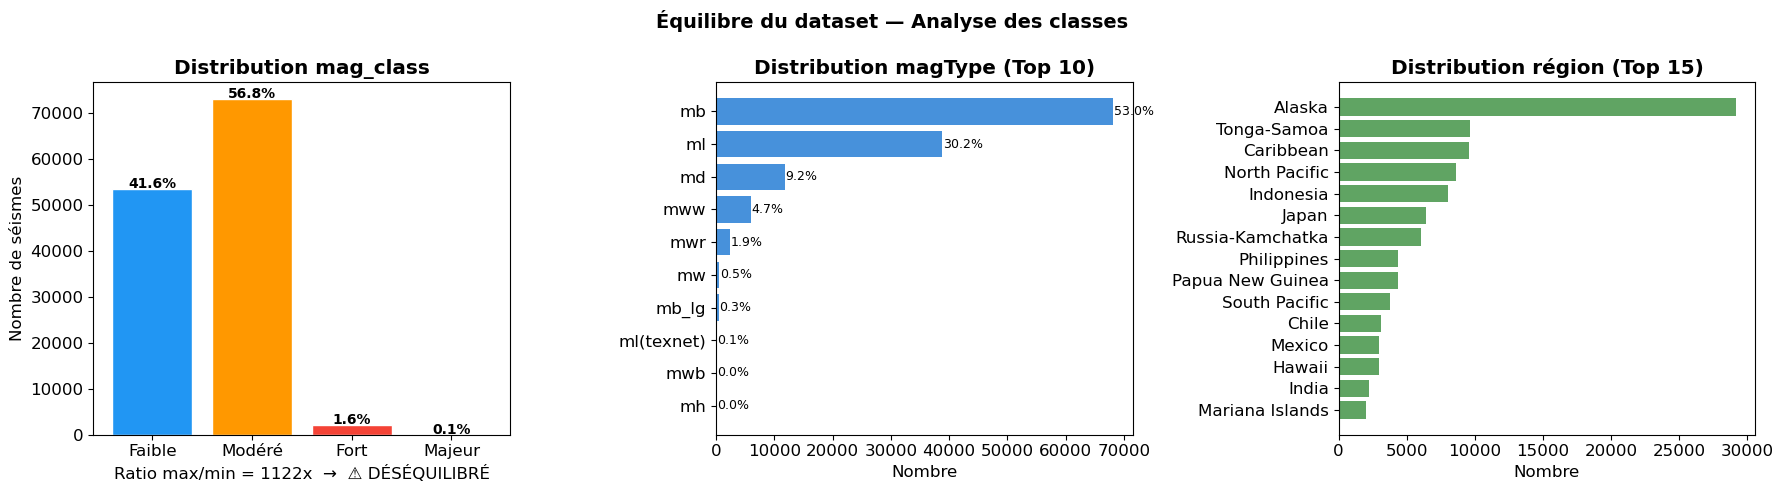


  RAPPORT DÉSÉQUILIBRE — mag_class
  Faible   :  53,396 ( 41.6%)  ████████████████████
  Modéré   :  72,939 ( 56.8%)  ████████████████████████████
  Fort     :   2,060 (  1.6%)  
  Majeur   :      65 (  0.1%)  

  Ratio max/min : 1122x
  ⚠️  TRÈS DÉSÉQUILIBRÉ → appliquer SMOTE ou class_weight='balanced'


In [50]:
# ═══════════════════════════════════════════════════════════════
# PARTIE 1 — ÉQUILIBRE DU DATASET
# Question : les classes sont-elles bien représentées ?
# ═══════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Équilibre du dataset — Analyse des classes", fontweight='bold', fontsize=14)

COLORS = {'Faible':'#2196F3','Modéré':'#FF9800','Fort':'#F44336','Majeur':'#9C27B0'}

# ── 1A : mag_class ──────────────────────────────────────────────
ordre = ['Faible','Modéré','Fort','Majeur']
dist  = df['mag_class'].value_counts().reindex(ordre)
bars  = axes[0].bar(dist.index, dist.values,
                    color=[COLORS[c] for c in dist.index], edgecolor='white')
for bar, val in zip(bars, dist.values):
    pct = val / len(df) * 100
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{pct:.1f}%', ha='center', fontsize=10, fontweight='bold')
axes[0].set_title('Distribution mag_class', fontweight='bold')
axes[0].set_ylabel('Nombre de séismes')

# Ratio déséquilibre
ratio = dist.max() / dist.min()
etat  = "⚠️ DÉSÉQUILIBRÉ" if ratio > 10 else "✅ Acceptable"
axes[0].set_xlabel(f'Ratio max/min = {ratio:.0f}x  →  {etat}')

# ── 1B : magType ────────────────────────────────────────────────
if 'magType' in df.columns:
    mag_type_dist = df['magType'].value_counts().head(10)
    axes[1].barh(mag_type_dist.index[::-1], mag_type_dist.values[::-1],
                 color='#1976D2', alpha=0.8)
    axes[1].set_title('Distribution magType (Top 10)', fontweight='bold')
    axes[1].set_xlabel('Nombre')
    for i, val in enumerate(mag_type_dist.values[::-1]):
        pct = val / len(df) * 100
        axes[1].text(val + 100, i, f'{pct:.1f}%', va='center', fontsize=9)

# ── 1C : region (Top 15) ────────────────────────────────────────
if 'region' in df.columns:
    region_dist = df['region'].value_counts().head(15)
    axes[2].barh(region_dist.index[::-1], region_dist.values[::-1],
                 color='#388E3C', alpha=0.8)
    axes[2].set_title('Distribution région (Top 15)', fontweight='bold')
    axes[2].set_xlabel('Nombre')

plt.tight_layout()
plt.savefig('equilibre_dataset.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Rapport déséquilibre ─────────────────────────────────────────
print("\n" + "="*55)
print("  RAPPORT DÉSÉQUILIBRE — mag_class")
print("="*55)
for cls in ordre:
    n   = dist[cls]
    pct = n / len(df) * 100
    bar = '█' * int(pct / 2)
    print(f"  {cls:8s} : {n:7,} ({pct:5.1f}%)  {bar}")

print(f"\n  Ratio max/min : {ratio:.0f}x")
if ratio > 20:
    print("  ⚠️  TRÈS DÉSÉQUILIBRÉ → appliquer SMOTE ou class_weight='balanced'")
elif ratio > 10:
    print("  ⚠️  DÉSÉQUILIBRÉ → utiliser class_weight='balanced' dans les modèles")
else:
    print("  ✅  Acceptable pour les modèles ML")

## Analyse des relations entre les variables

Nous étudions les corrélations entre les variables explicatives et la variable cible afin d'identifier les facteurs les plus influents.

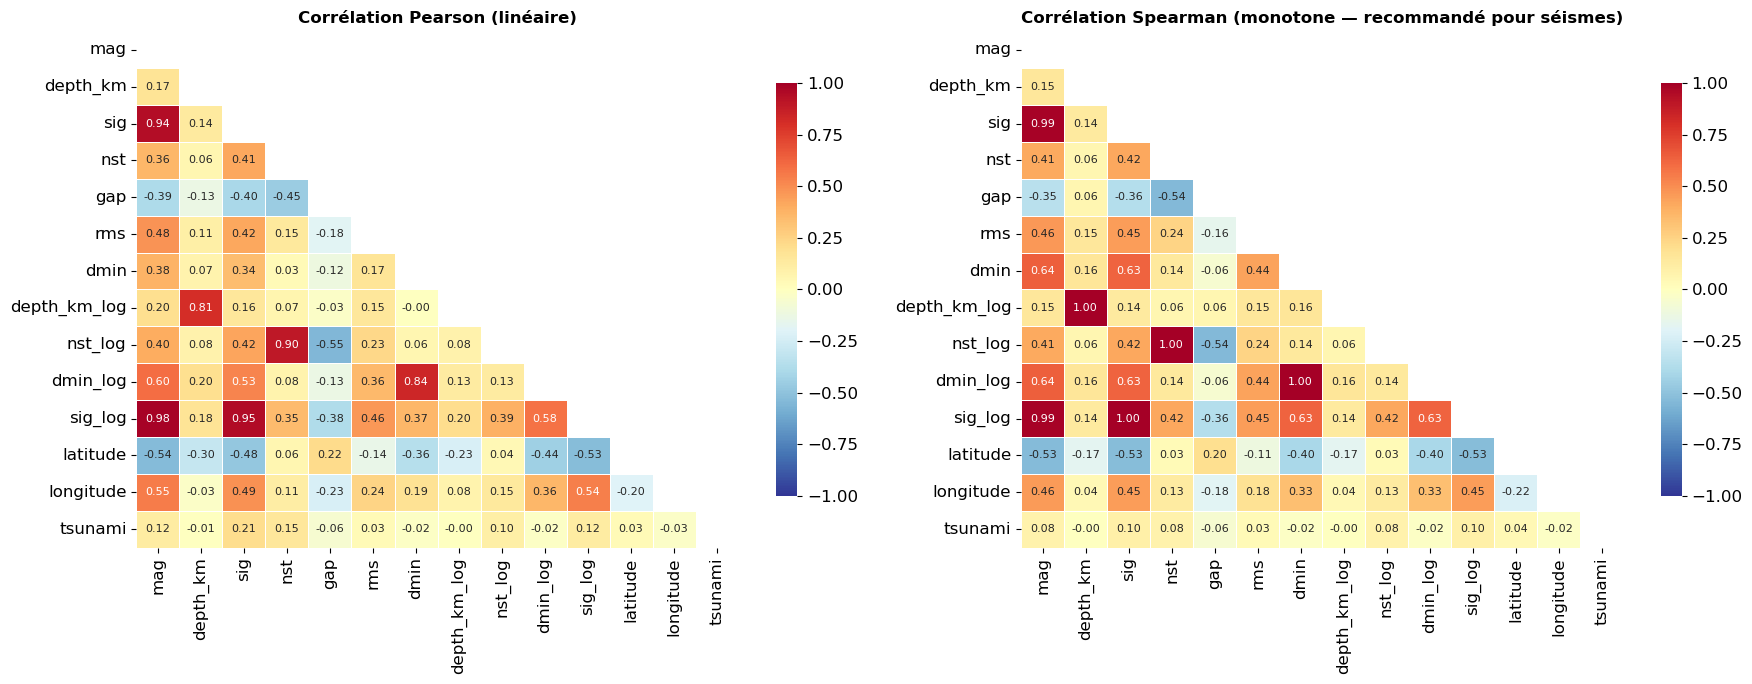


  Top corrélations avec 'mag' (Spearman) :
  ---------------------------------------------
  sig                  : +0.992  ★★★ Fort
  sig_log              : +0.992  ★★★ Fort
  dmin_log             : +0.644  ★★★ Fort
  dmin                 : +0.644  ★★★ Fort
  latitude             : -0.535  ★★★ Fort
  rms                  : +0.464  ★★★ Fort
  longitude            : +0.457  ★★★ Fort
  nst                  : +0.409  ★★★ Fort
  nst_log              : +0.409  ★★★ Fort
  gap                  : -0.347  ★★ Modéré
  depth_km             : +0.151  ★  Faible
  depth_km_log         : +0.151  ★  Faible
  tsunami              : +0.082  ★  Faible


In [51]:
# ═══════════════════════════════════════════════════════════════
# PARTIE 2 — CORRÉLATION NUMÉRIQUE (Pearson + Spearman)
# Complète et corrige votre cell 44 / 51
# ═══════════════════════════════════════════════════════════════
NUM_COLS = [c for c in ['mag','depth_km','sig','nst','gap','rms','dmin',
                         'depth_km_log','nst_log','dmin_log','sig_log',
                         'latitude','longitude','tsunami'] if c in df.columns]

CAT_COLS = [c for c in ['magType','region','mag_class'] if c in df.columns]
df_num = df[NUM_COLS].dropna()

corr_pearson  = df_num.corr(method='pearson')
corr_spearman = df_num.corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
mask = np.triu(np.ones_like(corr_pearson, dtype=bool))

for ax, corr, title in zip(axes,
    [corr_pearson, corr_spearman],
    ['Pearson (linéaire)', 'Spearman (monotone — recommandé pour séismes)']):
    sns.heatmap(corr, mask=mask, ax=ax,
                annot=True, fmt='.2f', cmap='RdYlBu_r',
                center=0, vmin=-1, vmax=1,
                linewidths=0.4, annot_kws={'size': 8},
                cbar_kws={'shrink': 0.8})
    ax.set_title(f'Corrélation {title}', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig('correlation_num.png', dpi=150, bbox_inches='tight')
plt.show()

# Top corrélations avec mag
print("\n  Top corrélations avec 'mag' (Spearman) :")
print("  " + "-"*45)
top = corr_spearman['mag'].drop('mag').sort_values(key=abs, ascending=False)
for col, val in top.items():
    force = '★★★ Fort' if abs(val)>0.4 else '★★ Modéré' if abs(val)>0.2 else '★  Faible'
    print(f"  {col:20s} : {val:+.3f}  {force}")

C:\Users\ISRAA\AppData\Local\Temp\ipykernel_15500\425517175.py:28: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

C:\Users\ISRAA\AppData\Local\Temp\ipykernel_15500\425517175.py:28: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

C:\Users\ISRAA\AppData\Local\Temp\ipykernel_15500\425517175.py:28: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

C:\Users\ISRAA\AppData\Local\Temp\ipykernel_15500\425517175.py:28: FutureWarning:

Th

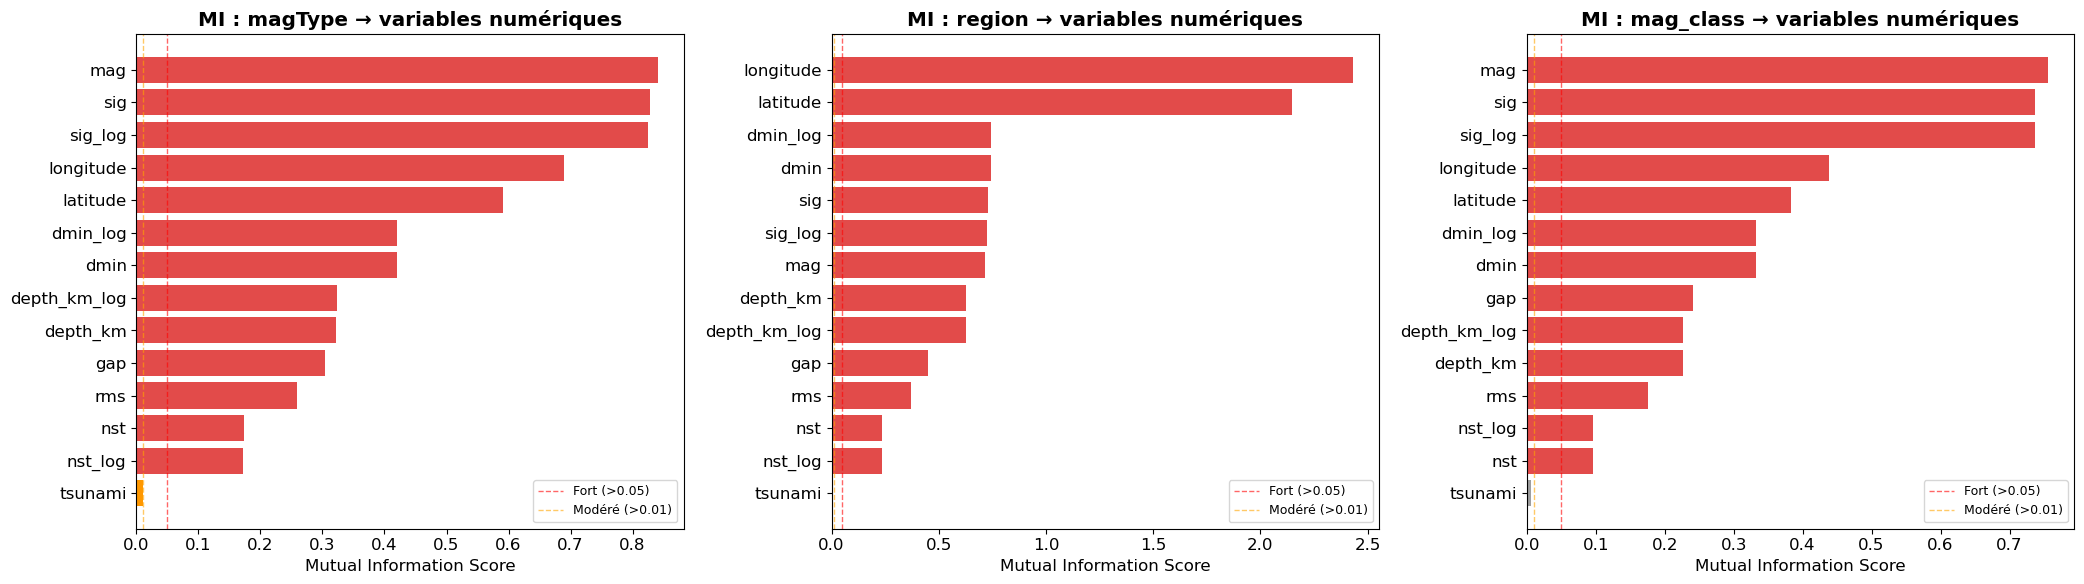


Top 15 relations (Mutual Information) :
  cat_col   num_col  MI_score
   region longitude    2.4305
   region  latitude    2.1458
  magType       mag    0.8403
  magType       sig    0.8277
  magType   sig_log    0.8250
mag_class       mag    0.7556
   region  dmin_log    0.7452
   region      dmin    0.7425
mag_class       sig    0.7369
mag_class   sig_log    0.7363
   region       sig    0.7289
   region   sig_log    0.7266
   region       mag    0.7176
  magType longitude    0.6891
   region  depth_km    0.6267

Kruskal-Wallis — relations significatives :
  42/42 paires sont significatives (p < 0.05)
  cat_col   num_col  p_value       relation
  magType       mag      0.0 ✅ Significatif
   region   nst_log      0.0 ✅ Significatif
   region  dmin_log      0.0 ✅ Significatif
   region   sig_log      0.0 ✅ Significatif
   region  latitude      0.0 ✅ Significatif
   region longitude      0.0 ✅ Significatif
mag_class       mag      0.0 ✅ Significatif
mag_class  depth_km      0.0 ✅ Signi

In [ ]:
# ═══════════════════════════════════════════════════════════════
# PARTIE 3 — KRUSKAL-WALLIS + MUTUAL INFORMATION
# Kruskal = ANOVA robuste (non-paramétrique, adapté aux séismes)
# MI      = détecte les relations NON-linéaires aussi
# ═══════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import kruskal
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import mutual_info_regression

results_kruskal = []
results_mi      = []

le = LabelEncoder()

for cat in CAT_COLS:
    for num in NUM_COLS:
        tmp = df[[cat, num]].dropna()
        if len(tmp) < 10:
            continue

        # ── Kruskal-Wallis ───────────────────────────────────────
        groups = [g[num].values for _, g in tmp.groupby(cat) if len(g) > 1]
        if len(groups) >= 2:
            stat, p = kruskal(*groups)
            results_kruskal.append({
                'cat_col' : cat,
                'num_col' : num,
                'p_value' : p,
                'relation': '✅ Significatif' if p < 0.05 else '❌ Non significatif'
            })

        # ── Mutual Information ───────────────────────────────────
        X = le.fit_transform(tmp[cat].astype(str)).reshape(-1, 1)
        y = tmp[num].values
        mi = mutual_info_regression(X, y, random_state=42)[0]
        results_mi.append({
            'cat_col' : cat,
            'num_col' : num,
            'MI_score': round(mi, 4)
        })

df_kruskal = pd.DataFrame(results_kruskal).sort_values('p_value')
df_mi_res  = pd.DataFrame(results_mi).sort_values('MI_score', ascending=False)

# ── Visualisation MI ─────────────────────────────────────────────
fig, axes = plt.subplots(1, len(CAT_COLS), figsize=(7*len(CAT_COLS), 6))
if len(CAT_COLS) == 1:
    axes = [axes]

for ax, cat in zip(axes, CAT_COLS):
    sub = df_mi_res[df_mi_res['cat_col'] == cat].sort_values('MI_score')
    colors = ['#E24B4A' if v > 0.05 else '#FF9800' if v > 0.01 else '#9E9E9E'
              for v in sub['MI_score']]
    ax.barh(sub['num_col'], sub['MI_score'], color=colors)
    ax.set_title(f'MI : {cat} → variables numériques', fontweight='bold')
    ax.set_xlabel('Mutual Information Score')
    ax.axvline(0.05, color='red',  linestyle='--', linewidth=1, alpha=0.6, label='Fort (>0.05)')
    ax.axvline(0.01, color='orange', linestyle='--', linewidth=1, alpha=0.6, label='Modéré (>0.01)')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('mutual_information.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 15 relations (Mutual Information) :")
print(df_mi_res.head(15).to_string(index=False))

print("\nKruskal-Wallis — relations significatives :")
sig = df_kruskal[df_kruskal['p_value'] < 0.05]
print(f"  {len(sig)}/{len(df_kruskal)} paires sont significatives (p < 0.05)")
print(df_kruskal.head(10).to_string(index=False))

In [53]:
df.head()

,time_utc,longitude,latitude,depth_km,place,mag,magType,nst,gap,dmin,...,sig_log,week,dayofweek,quarter,yearweek,month_name,day_name,region,mag_class,mag_class_num
0,2026-05-05 23:10:51,126.8824,7.9301,35.00,"45 km NE of Kinablangan, Philippines",4.6,mb,22.0,125.0,1.549,...,5.789960,19,1,2,2026-05-04/2026-05-10,Mai,Mar,Philippines,Modéré,1
1,2026-05-05 23:02:33,15.4546,39.8560,298.62,"18 km SSE of Marina di Camerota, Italy",4.1,mb,37.0,156.0,0.309,...,5.560682,19,1,2,2026-05-04/2026-05-10,Mai,Mar,Italy,Modéré,1
2,2026-05-05 22:57:40,-153.0290,60.3940,141.60,"74 km ENE of Port Alsworth, Alaska",3.5,ml,219.0,33.0,0.100,...,5.241747,19,1,2,2026-05-04/2026-05-10,Mai,Mar,Alaska,Faible,0
5,2026-05-05 22:02:01,59.7089,60.2993,10.00,"16 km WSW of Cherëmukhovo, Russia",4.4,mb,47.0,94.0,9.314,...,5.700444,19,1,2,2026-05-04/2026-05-10,Mai,Mar,Russia-Kamchatka,Modéré,1
6,2026-05-05 21:37:25,60.0612,60.4048,10.00,"7 km NE of Cherëmukhovo, Russia",4.2,mb,30.0,96.0,9.273,...,5.605802,19,1,2,2026-05-04/2026-05-10,Mai,Mar,Russia-Kamchatka,Modéré,1


In [54]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
df['mag_class_merged'] = df['mag_class'].replace({
    'Fort': 'Strong',
    'Majeur': 'Strong'
})
le = LabelEncoder()
df['mag_class_num_merged'] = le.fit_transform(df['mag_class_merged'])

print("Classes:", le.classes_)


Classes: ['Faible' 'Modéré' 'Strong']


C:\Users\ISRAA\AppData\Local\Temp\ipykernel_15500\1119512203.py:7: FutureWarning:

The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.



In [55]:
df.head()

,time_utc,longitude,latitude,depth_km,place,mag,magType,nst,gap,dmin,...,dayofweek,quarter,yearweek,month_name,day_name,region,mag_class,mag_class_num,mag_class_merged,mag_class_num_merged
0,2026-05-05 23:10:51,126.8824,7.9301,35.00,"45 km NE of Kinablangan, Philippines",4.6,mb,22.0,125.0,1.549,...,1,2,2026-05-04/2026-05-10,Mai,Mar,Philippines,Modéré,1,Modéré,1
1,2026-05-05 23:02:33,15.4546,39.8560,298.62,"18 km SSE of Marina di Camerota, Italy",4.1,mb,37.0,156.0,0.309,...,1,2,2026-05-04/2026-05-10,Mai,Mar,Italy,Modéré,1,Modéré,1
2,2026-05-05 22:57:40,-153.0290,60.3940,141.60,"74 km ENE of Port Alsworth, Alaska",3.5,ml,219.0,33.0,0.100,...,1,2,2026-05-04/2026-05-10,Mai,Mar,Alaska,Faible,0,Faible,0
5,2026-05-05 22:02:01,59.7089,60.2993,10.00,"16 km WSW of Cherëmukhovo, Russia",4.4,mb,47.0,94.0,9.314,...,1,2,2026-05-04/2026-05-10,Mai,Mar,Russia-Kamchatka,Modéré,1,Modéré,1
6,2026-05-05 21:37:25,60.0612,60.4048,10.00,"7 km NE of Cherëmukhovo, Russia",4.2,mb,30.0,96.0,9.273,...,1,2,2026-05-04/2026-05-10,Mai,Mar,Russia-Kamchatka,Modéré,1,Modéré,1


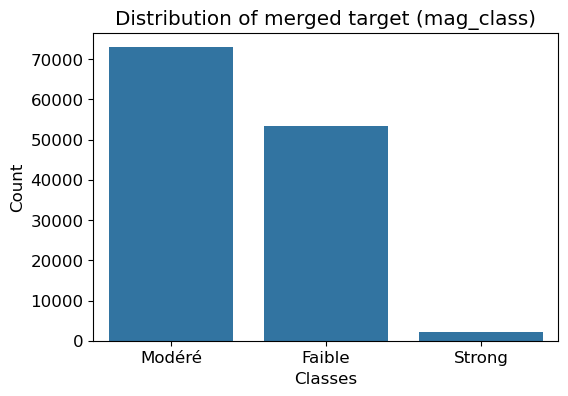

In [56]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(x='mag_class_merged', data=df, order=df['mag_class_merged'].value_counts().index)

plt.title("Distribution of merged target (mag_class)")
plt.xlabel("Classes")
plt.ylabel("Count")
plt.show()

In [57]:
df.to_csv("dataset_version1.csv", index=False)

In [58]:
import pandas as pd

df_v1 = pd.read_csv("dataset_version1.csv")

df_v1.head()

,time_utc,longitude,latitude,depth_km,place,mag,magType,nst,gap,dmin,...,dayofweek,quarter,yearweek,month_name,day_name,region,mag_class,mag_class_num,mag_class_merged,mag_class_num_merged
0,2026-05-05 23:10:51,126.8824,7.9301,35.00,"45 km NE of Kinablangan, Philippines",4.6,mb,22.0,125.0,1.549,...,1,2,2026-05-04/2026-05-10,Mai,Mar,Philippines,Modéré,1,Modéré,1
1,2026-05-05 23:02:33,15.4546,39.8560,298.62,"18 km SSE of Marina di Camerota, Italy",4.1,mb,37.0,156.0,0.309,...,1,2,2026-05-04/2026-05-10,Mai,Mar,Italy,Modéré,1,Modéré,1
2,2026-05-05 22:57:40,-153.0290,60.3940,141.60,"74 km ENE of Port Alsworth, Alaska",3.5,ml,219.0,33.0,0.100,...,1,2,2026-05-04/2026-05-10,Mai,Mar,Alaska,Faible,0,Faible,0
3,2026-05-05 22:02:01,59.7089,60.2993,10.00,"16 km WSW of Cherëmukhovo, Russia",4.4,mb,47.0,94.0,9.314,...,1,2,2026-05-04/2026-05-10,Mai,Mar,Russia-Kamchatka,Modéré,1,Modéré,1
4,2026-05-05 21:37:25,60.0612,60.4048,10.00,"7 km NE of Cherëmukhovo, Russia",4.2,mb,30.0,96.0,9.273,...,1,2,2026-05-04/2026-05-10,Mai,Mar,Russia-Kamchatka,Modéré,1,Modéré,1


In [59]:
df_v1.columns

Index(['time_utc', 'longitude', 'latitude', 'depth_km', 'place', 'mag',
       'magType', 'nst', 'gap', 'dmin', 'rms', 'net', 'tsunami', 'sig', 'year',
       'month', 'day', 'hour', 'depth_km_log', 'nst_log', 'dmin_log',
       'sig_log', 'week', 'dayofweek', 'quarter', 'yearweek', 'month_name',
       'day_name', 'region', 'mag_class', 'mag_class_num', 'mag_class_merged',
       'mag_class_num_merged'],
      dtype='object')

In [60]:

df['net'].head()

0    us
1    us
2    ak
5    us
6    us
Name: net, dtype: object

In [61]:
# ══════════════════════════════════════════════════════════════
# ÉTAPE 1 — NETTOYAGE FINAL
# Supprimer UNIQUEMENT les colonnes texte redondantes
# ══════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np

df = pd.read_csv('dataset_version1.csv')
df['time_utc'] = pd.to_datetime(df['time_utc'])

# Supprimer SEULEMENT les colonnes texte redondantes
# (les versions numériques sont déjà présentes)
cols_to_drop = [
    'depth_km', 'place', 'mag', 'dmin', 'nst', 'sig',
    'year', 'month', 'day', 'hour',
    'week', 'dayofweek', 'quarter', 'yearweek',
    'month_name', 'day_name',
    'region', 'mag_class', 'mag_class_num'
]

df = df.drop(columns=cols_to_drop, errors='ignore')

print(f"✅ Dataset nettoyé : {df.shape[0]:,} lignes | {df.shape[1]} colonnes")
print(f"\nColonnes restantes :")
for c in df.columns:
    print(f"  → {c} ({df[c].dtype}) | NaN: {df[c].isnull().sum()}")

✅ Dataset nettoyé : 128,460 lignes | 14 colonnes

Colonnes restantes :
  → time_utc (datetime64[ns]) | NaN: 0
  → longitude (float64) | NaN: 0
  → latitude (float64) | NaN: 0
  → magType (object) | NaN: 0
  → gap (float64) | NaN: 0
  → rms (float64) | NaN: 0
  → net (object) | NaN: 0
  → tsunami (int64) | NaN: 0
  → depth_km_log (float64) | NaN: 0
  → nst_log (float64) | NaN: 0
  → dmin_log (float64) | NaN: 0
  → sig_log (float64) | NaN: 0
  → mag_class_merged (object) | NaN: 0
  → mag_class_num_merged (int64) | NaN: 0


In [62]:
# ══════════════════════════════════════════════════════════════
# ÉTAPE 2 — ANALYSE CORRÉLATION AVEC TARGET = mag_class_num_merged
# ══════════════════════════════════════════════════════════════
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

# Colonnes numériques uniquement (sans target, sans time, sans texte)
cols_num = [
    'latitude',
    'longitude',
    'gap',
    'rms',
    'tsunami',
    'depth_km_log',
    'nst_log',
    'dmin_log',
    'sig_log', 'mag_class_num_merged'
]

df_corr = df[cols_num].dropna()

# ── Corrélation avec le target ────────────────
corr = df_corr.corr()['mag_class_num_merged'].drop('mag_class_num_merged')
corr_abs = corr.abs().sort_values(ascending=False)

print("📊 CORRÉLATION avec mag_class_num_merged (target) :")
print("="*50)
for feat, val in corr_abs.items():
    signe = "+" if corr[feat] > 0 else "-"
    barre = "█" * int(abs(val) * 30)
    print(f"  {feat:20s} : {signe}{abs(val):.4f}  {barre}")

print(f"\n✅ Features UTILES  (|corr| > 0.05) :")
utiles = corr_abs[corr_abs > 0.05].index.tolist()
print(utiles)

print(f"\n⚠️  Features FAIBLES (|corr| ≤ 0.05) :")
faibles = corr_abs[corr_abs <= 0.05].index.tolist()
print(faibles)

📊 CORRÉLATION avec mag_class_num_merged (target) :
  sig_log              : +0.8957  ██████████████████████████
  dmin_log             : +0.6059  ██████████████████
  longitude            : +0.5706  █████████████████
  latitude             : -0.5457  ████████████████
  rms                  : +0.4840  ██████████████
  gap                  : -0.4106  ████████████
  nst_log              : +0.3402  ██████████
  depth_km_log         : +0.2340  ███████
  tsunami              : +0.1000  ███

✅ Features UTILES  (|corr| > 0.05) :
['sig_log', 'dmin_log', 'longitude', 'latitude', 'rms', 'gap', 'nst_log', 'depth_km_log', 'tsunami']

⚠️  Features FAIBLES (|corr| ≤ 0.05) :
[]


C:\Users\ISRAA\AppData\Local\Temp\ipykernel_15500\3527146416.py:16: UserWarning:

Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.

C:\Users\ISRAA\AppData\Local\Temp\ipykernel_15500\3527146416.py:17: UserWarning:

Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.

C:\Users\ISRAA\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning:

Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.



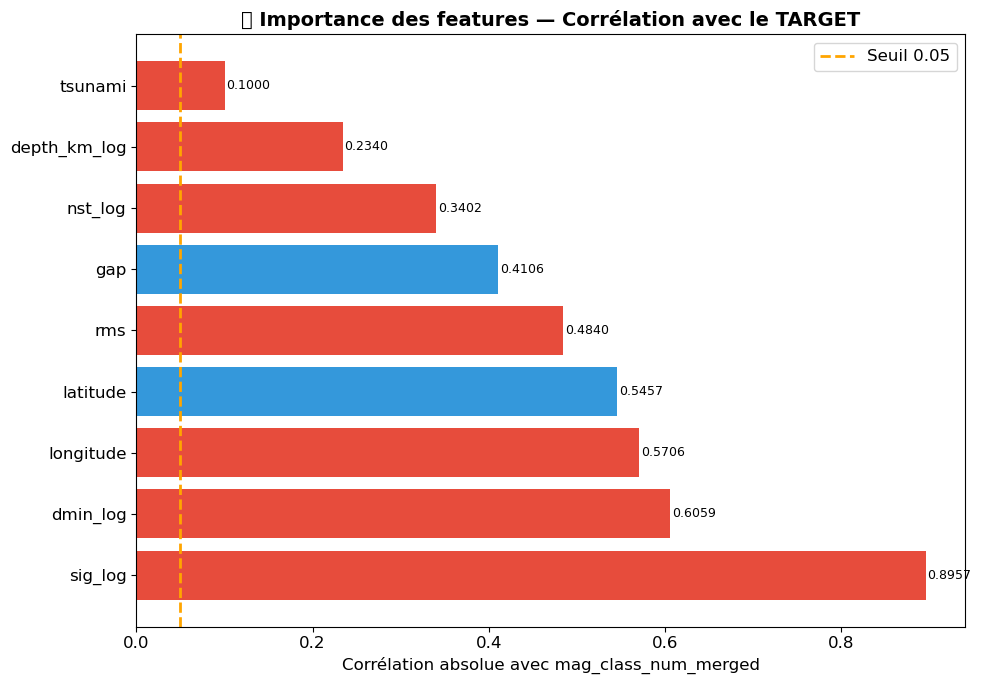

In [63]:
# ── Barplot corrélation ───────────────────────
fig, ax = plt.subplots(figsize=(10, 7))

colors = ['#e74c3c' if v > 0 else '#3498db' for v in corr[corr_abs.index]]
bars = ax.barh(corr_abs.index, corr_abs.values, color=colors)

ax.set_xlabel('Corrélation absolue avec mag_class_num_merged', fontsize=12)
ax.set_title('📊 Importance des features — Corrélation avec le TARGET', fontsize=14, fontweight='bold')
ax.axvline(x=0.05, color='orange', linestyle='--', linewidth=2, label='Seuil 0.05')
ax.legend()

for bar, val in zip(bars, corr_abs.values):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('correlation_target.png', dpi=150, bbox_inches='tight')
plt.show()

## Analyse du déséquilibre des classes

La distribution de la variable cible est analysée afin de détecter un éventuel déséquilibre pouvant affecter les performances des modèles.

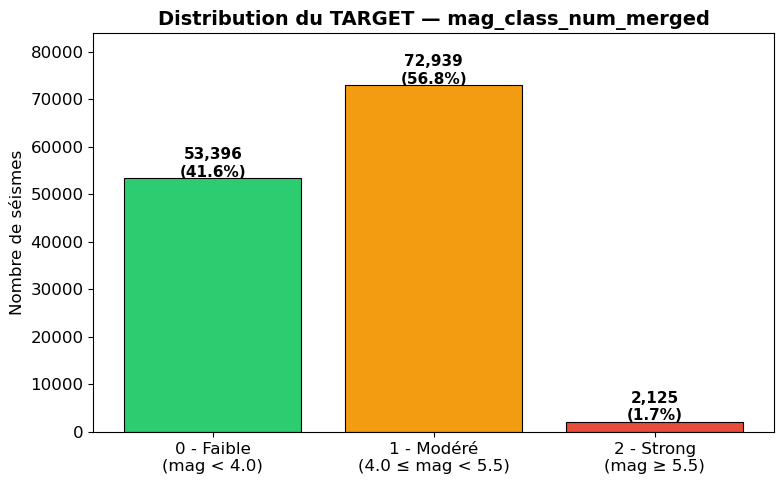


📊 Distribution du target :
   Classe 0 (0 - Faible) : 53,396 (41.6%)
   Classe 1 (1 - Modéré) : 72,939 (56.8%)
   Classe 2 (2 - Strong) : 2,125 (1.7%)

⚠️  Ratio déséquilibre : 34.3x
→ 🔴 SMOTE obligatoire (ratio très élevé)


In [64]:
# ══════════════════════════════════════════════════════════════
# ÉTAPE 3 — VÉRIFIER DÉSÉQUILIBRE DU TARGET
# ══════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(8, 5))

labels_map = {0: '0 - Faible\n(mag < 4.0)',
              1: '1 - Modéré\n(4.0 ≤ mag < 5.5)',
              2: '2 - Strong\n(mag ≥ 5.5)'}

dist = df['mag_class_num_merged'].value_counts().sort_index()
pct  = (dist / dist.sum() * 100).round(1)

bars = ax.bar(
    [labels_map[i] for i in dist.index],
    dist.values,
    color=['#2ecc71', '#f39c12', '#e74c3c'],
    edgecolor='black', linewidth=0.8
)

for bar, count, p in zip(bars, dist.values, pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
            f'{count:,}\n({p}%)', ha='center', fontweight='bold', fontsize=11)

ax.set_title('Distribution du TARGET — mag_class_num_merged', fontsize=14, fontweight='bold')
ax.set_ylabel('Nombre de séismes')
ax.set_ylim(0, dist.max() * 1.15)
plt.tight_layout()
plt.savefig('target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Diagnostic déséquilibre ───────────────────
ratio = dist.max() / dist.min()
print(f"\n📊 Distribution du target :")
for i, (count, p) in enumerate(zip(dist.values, pct.values)):
    print(f"   Classe {i} ({labels_map[i].split(chr(10))[0]}) : {count:,} ({p}%)")

print(f"\n⚠️  Ratio déséquilibre : {ratio:.1f}x")
if ratio > 10:
    print("→ 🔴 SMOTE obligatoire (ratio très élevé)")
elif ratio > 3:
    print("→ 🟡 SMOTE recommandé OU class_weight='balanced'")
else:
    print("→ 🟢 class_weight='balanced' suffit")

## Analyse des variables catégorielles

Nous utilisons le test du Chi² ainsi que la mesure de Cramér's V pour évaluer l'influence des variables catégorielles sur la variable cible.

In [65]:
# ══════════════════════════════════════════════════════════════
# CORRÉLATION VARIABLES CATÉGORIELLES vs TARGET
# Test Chi² + Cramér's V
# Variables : magType, net, region
# Target    : mag_class_num_merged
# ══════════════════════════════════════════════════════════════
from scipy.stats import chi2_contingency
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def cramers_v(col1, col2):
    """Cramér's V — force de la relation entre 2 variables catégorielles."""
    ct = pd.crosstab(col1, col2)
    chi2, p, dof, _ = chi2_contingency(ct)
    n = ct.sum().sum()
    r, k = ct.shape
    v = np.sqrt(chi2 / (n * (min(r, k) - 1)))
    return round(v, 4), round(p, 6)

# Variables catégorielles à tester
cat_cols = [c for c in ['magType', 'net', 'region'] if c in df.columns]
target   = 'mag_class_num_merged'

print("📊 TEST CHI² + CRAMÉR'S V — Variables catégorielles vs Target")
print("="*65)
print(f"{'Variable':<12} {'Cramér V':>10} {'p-value':>12} {'Relation':>20}")
print("─"*65)

cramer_results = []
for col in cat_cols:
    v, p = cramers_v(df[col].astype(str), df[target])
    if p < 0.001:
        sig = "✅ Très significatif"
    elif p < 0.05:
        sig = "✅ Significatif"
    else:
        sig = "❌ Non significatif"

    if v > 0.3:
        force = "🔴 Fort"
    elif v > 0.1:
        force = "🟡 Modéré"
    else:
        force = "🟢 Faible"

    print(f"{col:<12} {v:>10} {p:>12} {force + ' — ' + sig:>35}")
    cramer_results.append({'Variable': col, 'Cramér V': v, 'p-value': p})

df_cramer = pd.DataFrame(cramer_results).sort_values('Cramér V', ascending=False)

📊 TEST CHI² + CRAMÉR'S V — Variables catégorielles vs Target
Variable       Cramér V      p-value             Relation
─────────────────────────────────────────────────────────────────
magType          0.7695          0.0        🔴 Fort — ✅ Très significatif
net              0.4544          0.0        🔴 Fort — ✅ Très significatif


In [66]:
df.head()

,time_utc,longitude,latitude,magType,gap,rms,net,tsunami,depth_km_log,nst_log,dmin_log,sig_log,mag_class_merged,mag_class_num_merged
0,2026-05-05 23:10:51,126.8824,7.9301,mb,125.0,0.57,us,0,3.583519,3.135494,0.935701,5.789960,Modéré,1
1,2026-05-05 23:02:33,15.4546,39.8560,mb,156.0,0.71,us,0,5.702515,3.637586,0.269263,5.560682,Modéré,1
2,2026-05-05 22:57:40,-153.0290,60.3940,ml,33.0,1.00,ak,0,4.960044,5.393628,0.095310,5.241747,Faible,0
3,2026-05-05 22:02:01,59.7089,60.2993,mb,94.0,0.60,us,0,2.397895,3.871201,2.333502,5.700444,Modéré,1
4,2026-05-05 21:37:25,60.0612,60.4048,mb,96.0,0.58,us,0,2.397895,3.433987,2.329519,5.605802,Modéré,1


In [67]:
df['time_utc'] = pd.to_datetime(df['time_utc'])

df['hour'] = df['time_utc'].dt.hour
df['dayofweek'] = df['time_utc'].dt.dayofweek
df['month'] = df['time_utc'].dt.month

df = df.drop(columns=['time_utc'])

In [68]:
df.head()

,longitude,latitude,magType,gap,rms,net,tsunami,depth_km_log,nst_log,dmin_log,sig_log,mag_class_merged,mag_class_num_merged,hour,dayofweek,month
0,126.8824,7.9301,mb,125.0,0.57,us,0,3.583519,3.135494,0.935701,5.789960,Modéré,1,23,1,5
1,15.4546,39.8560,mb,156.0,0.71,us,0,5.702515,3.637586,0.269263,5.560682,Modéré,1,23,1,5
2,-153.0290,60.3940,ml,33.0,1.00,ak,0,4.960044,5.393628,0.095310,5.241747,Faible,0,22,1,5
3,59.7089,60.2993,mb,94.0,0.60,us,0,2.397895,3.871201,2.333502,5.700444,Modéré,1,22,1,5
4,60.0612,60.4048,mb,96.0,0.58,us,0,2.397895,3.433987,2.329519,5.605802,Modéré,1,21,1,5


# 🤖 Construction des modèles de Machine Learning

Après le nettoyage et l’analyse des données, nous préparons les variables d'entrée et la variable cible pour l’apprentissage supervisé.

In [69]:
df = df.drop(columns=['mag_class_merged'])

In [70]:
df.columns

Index(['longitude', 'latitude', 'magType', 'gap', 'rms', 'net', 'tsunami',
       'depth_km_log', 'nst_log', 'dmin_log', 'sig_log',
       'mag_class_num_merged', 'hour', 'dayofweek', 'month'],
      dtype='object')

## Préparation des données

Les données sont séparées en ensembles d'entraînement et de test afin d'évaluer objectivement les performances des modèles.

In [71]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

# 1. Target
y = df['mag_class_num_merged']

# 2. Features
cols_exclure = ['mag_class_num_merged', 'magType']
X = df.drop(columns=[c for c in cols_exclure if c in df.columns])

# 3. Split FIRST
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Separate numeric and categorical columns
num_cols = X_train.select_dtypes(include='number').columns.tolist()
cat_cols = X_train.select_dtypes(exclude='number').columns.tolist()

print(f"🔢 Numeric columns   : {len(num_cols)}")
print(f"🔤 Categorical columns: {cat_cols}")

# 5. Impute numeric with median
num_imputer = SimpleImputer(strategy='median')
X_train_num = pd.DataFrame(num_imputer.fit_transform(X_train[num_cols]), columns=num_cols)
X_test_num  = pd.DataFrame(num_imputer.transform(X_test[num_cols]),      columns=num_cols)

# 6. Impute categorical with most_frequent
if cat_cols:
    cat_imputer = SimpleImputer(strategy='most_frequent')
    X_train_cat = pd.DataFrame(cat_imputer.fit_transform(X_train[cat_cols]), columns=cat_cols)
    X_test_cat  = pd.DataFrame(cat_imputer.transform(X_test[cat_cols]),      columns=cat_cols)

    # 7. One-hot encode categorical columns
    X_train_cat = pd.get_dummies(X_train_cat, columns=cat_cols)
    X_test_cat  = X_test_cat.reindex(columns=X_train_cat.columns, fill_value=0)  # align columns

    # 8. Recombine
    X_train = pd.concat([X_train_num.reset_index(drop=True), X_train_cat.reset_index(drop=True)], axis=1)
    X_test  = pd.concat([X_test_num.reset_index(drop=True),  X_test_cat.reset_index(drop=True)],  axis=1)
else:
    X_train = X_train_num
    X_test  = X_test_num

# 9. Info
print(f"\n✅ Ready for ML")
print(f"Train shape : {X_train.shape}")
print(f"Test shape  : {X_test.shape}")

🔢 Numeric columns   : 12
🔤 Categorical columns: ['net']

✅ Ready for ML
Train shape : (102768, 28)
Test shape  : (25692, 28)


In [72]:
print(y_train.value_counts().sort_index())
print("\n📊 Distribution (%):")
print(y_train.value_counts(normalize=True).sort_index() * 100)

mag_class_num_merged
0    42717
1    58351
2     1700
Name: count, dtype: int64

📊 Distribution (%):
mag_class_num_merged
0    41.566441
1    56.779348
2     1.654211
Name: proportion, dtype: float64


## Entraînement et comparaison des modèles

Plusieurs algorithmes de Machine Learning sont entraînés et comparés :

- Random Forest
- XGBoost
- Gradient Boosting
- Decision Tree
- KNN
- Logistic Regression
- SVM

Les performances sont évaluées à l’aide des métriques Accuracy, F1-Score et Validation Croisée.

## Équilibrage des classes

Le dataset présente un déséquilibre important entre les différentes catégories de séismes.

La technique SMOTE est utilisée pour générer artificiellement des observations des classes minoritaires.

In [73]:
# ══════════════════════════════════════════════════════════════
# IMPORTS
# ══════════════════════════════════════════════════════════════
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import StratifiedKFold, cross_val_score
import time
import pandas as pd

# ══════════════════════════════════════════════════════════════
# DÉFINITION DES MODÈLES
# ══════════════════════════════════════════════════════════════
models_def = {
    'Random Forest'      : RandomForestClassifier(
                                n_estimators=200, max_depth=10,
                                min_samples_leaf=5, class_weight='balanced',
                                random_state=42, n_jobs=-1),
    'XGBoost'            : XGBClassifier(
                                n_estimators=200, max_depth=4,
                                learning_rate=0.05, subsample=0.8,
                                eval_metric='mlogloss',
                                random_state=42, n_jobs=-1),
    'Gradient Boosting'  : GradientBoostingClassifier(
                                n_estimators=100, max_depth=4,
                                learning_rate=0.05, random_state=42),
    'Decision Tree'      : DecisionTreeClassifier(
                                max_depth=10, min_samples_leaf=5,
                                class_weight='balanced', random_state=42),
    'KNN'                : KNeighborsClassifier(n_neighbors=7, n_jobs=-1),
    'Logistic Regression': LogisticRegression(
                                class_weight='balanced',
                                max_iter=1000, random_state=42),
    'SVM'                : SVC(
                                class_weight='balanced',
                                kernel='rbf', random_state=42),
}

# ══════════════════════════════════════════════════════════════
# CONSTRUCTION DES PIPELINES
# Ordre : SMOTE → StandardScaler → Modèle
# ══════════════════════════════════════════════════════════════
def build_pipeline(model):
    return ImbPipeline([
        ('smote',  SMOTE(random_state=42)),
        ('scaler', StandardScaler()),        # ← ajouté pour tous
        ('model',  model)
    ])

# ══════════════════════════════════════════════════════════════
# ENTRAÎNEMENT + ÉVALUATION + CV
# ══════════════════════════════════════════════════════════════
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = []
trained = {}

print("⏳ Entraînement en cours...\n")
print(f"{'Modèle':<22} {'Accuracy':>10} {'F1-Macro':>10} {'F1-Weighted':>13} {'CV F1':>8} {'±':>6} {'Overfit?':>11} {'Temps':>7}")
print("─" * 95)

for name, model in models_def.items():
    pipe = build_pipeline(model)

    # CV sur X_train original (SMOTE + scaling à l'intérieur de chaque fold)
    cv_scores = cross_val_score(pipe, X_train, y_train,
                                cv=cv, scoring='f1_macro', n_jobs=-1)

    # Entraînement final + prédiction
    t0 = time.time()
    pipe.fit(X_train, y_train)
    y_pred  = pipe.predict(X_test)
    elapsed = time.time() - t0

    acc = accuracy_score(y_test, y_pred)
    f1m = f1_score(y_test, y_pred, average='macro')
    f1w = f1_score(y_test, y_pred, average='weighted')
    gap = cv_scores.mean() - f1m

    overfit = "🔴 OUI"       if gap > 0.05 else \
              "🟡 PEUT-ÊTRE" if gap > 0.02 else \
              "🟢 NON"

    results.append({
        'Modèle'      : name,
        'Accuracy'    : round(acc, 4),
        'F1-Macro'    : round(f1m, 4),
        'F1-Weighted' : round(f1w, 4),
        'CV F1-Macro' : round(cv_scores.mean(), 4),
        'CV ± std'    : round(cv_scores.std(),  4),
        'Gap'         : round(gap, 4),
        'Overfit'     : overfit,
        'Temps(s)'    : round(elapsed, 2),
    })
    trained[name] = pipe

    print(f"{name:<22} {acc:>10.4f} {f1m:>10.4f} {f1w:>13.4f} "
          f"{cv_scores.mean():>8.4f} {cv_scores.std():>6.4f} {overfit:>11} {elapsed:>6.1f}s")

# ══════════════════════════════════════════════════════════════
# RÉSULTATS FINAUX
# ══════════════════════════════════════════════════════════════
df_results = pd.DataFrame(results).sort_values('F1-Macro', ascending=False)

print("\n" + "═" * 95)
print(f"🏆 MEILLEUR MODÈLE : {df_results.iloc[0]['Modèle']}")
print(f"   F1-Macro   : {df_results.iloc[0]['F1-Macro']}")
print(f"   F1-Weighted: {df_results.iloc[0]['F1-Weighted']}")
print(f"   Accuracy   : {df_results.iloc[0]['Accuracy']}")
print(f"   CV F1-Macro: {df_results.iloc[0]['CV F1-Macro']} ± {df_results.iloc[0]['CV ± std']}")
print(f"   Overfitting: {df_results.iloc[0]['Overfit']}")

⏳ Entraînement en cours...

Modèle                   Accuracy   F1-Macro   F1-Weighted    CV F1      ±    Overfit?   Temps
───────────────────────────────────────────────────────────────────────────────────────────────
Random Forest              0.9970     0.9891        0.9970   0.9885 0.0021       🟢 NON   15.0s
XGBoost                    0.9972     0.9870        0.9972   0.9886 0.0021       🟢 NON    7.5s
Gradient Boosting          0.9968     0.9853        0.9968   0.9874 0.0019       🟢 NON  356.9s
Decision Tree              0.9758     0.6788        0.9686   0.9879 0.0022       🔴 OUI    5.6s
KNN                        0.9391     0.7861        0.9468   0.7944 0.0022       🟢 NON    9.5s
Logistic Regression        0.9507     0.6783        0.9445   0.9384 0.0040       🔴 OUI    4.9s
SVM                        0.9882     0.9555        0.9883   0.9367 0.0047       🟢 NON  213.3s

═══════════════════════════════════════════════════════════════════════════════════════════════
🏆 MEILLEUR MODÈLE :

## Sélection du meilleur modèle

Les performances obtenues permettent d’identifier le modèle offrant le meilleur compromis entre précision, robustesse et généralisation.

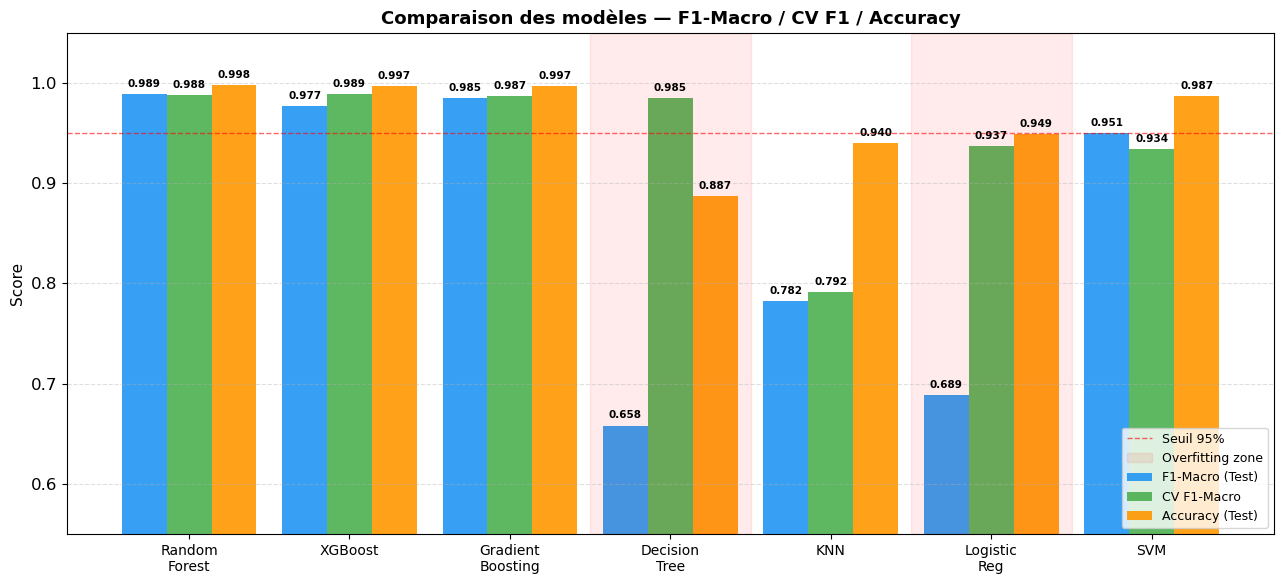

In [74]:
import matplotlib.pyplot as plt
import numpy as np

modeles = ['Random\nForest', 'XGBoost', 'Gradient\nBoosting', 'Decision\nTree', 'KNN', 'Logistic\nReg', 'SVM']
f1_macro   = [0.9885, 0.9767, 0.9849, 0.6583, 0.7823, 0.6888, 0.9505]
cv_f1      = [0.9878, 0.9885, 0.9871, 0.9854, 0.7919, 0.9370, 0.9342]
accuracy   = [0.9975, 0.9965, 0.9968, 0.8871, 0.9403, 0.9490, 0.9872]

x = np.arange(len(modeles))
width = 0.28

fig, ax = plt.subplots(figsize=(13, 6))

bars1 = ax.bar(x - width, f1_macro, width, label='F1-Macro (Test)',  color='#2196F3', alpha=0.9)
bars2 = ax.bar(x,          cv_f1,   width, label='CV F1-Macro',      color='#4CAF50', alpha=0.9)
bars3 = ax.bar(x + width,  accuracy,width, label='Accuracy (Test)',   color='#FF9800', alpha=0.9)

# Annotations
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.005,
                f'{h:.3f}', ha='center', va='bottom', fontsize=7.5, fontweight='bold')

# Ligne de référence
ax.axhline(y=0.95, color='red', linestyle='--', linewidth=1, alpha=0.6, label='Seuil 95%')

# Zones overfitting
ax.axvspan(2.5, 3.5, alpha=0.08, color='red', label='Overfitting zone')
ax.axvspan(4.5, 5.5, alpha=0.08, color='red')

ax.set_xticks(x)
ax.set_xticklabels(modeles, fontsize=10)
ax.set_ylim(0.55, 1.05)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Comparaison des modèles — F1-Macro / CV F1 / Accuracy', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

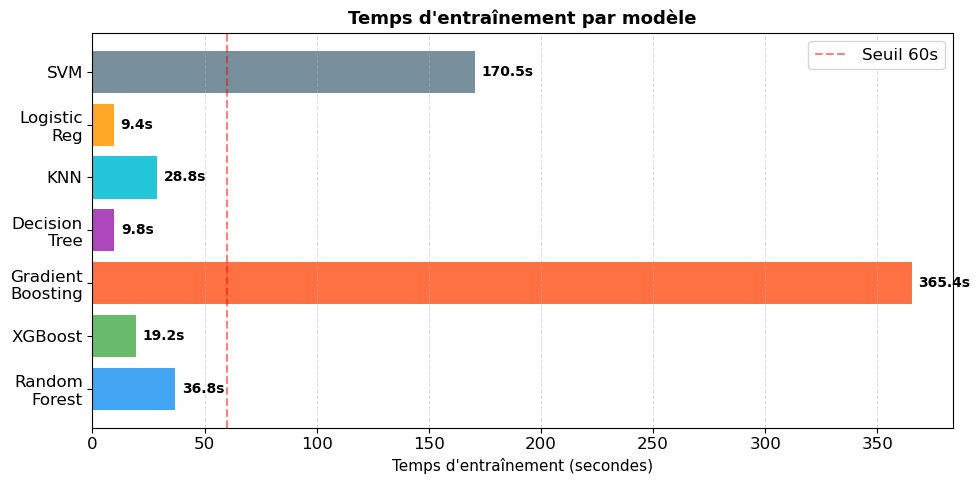

In [75]:
# Graphique temps d'entraînement
temps = [36.8, 19.2, 365.4, 9.8, 28.8, 9.4, 170.5]
colors = ['#2196F3', '#4CAF50', '#FF5722', '#9C27B0', '#00BCD4', '#FF9800', '#607D8B']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(modeles, temps, color=colors, alpha=0.85)

for bar, t in zip(bars, temps):
    ax.text(bar.get_width() + 3, bar.get_y() + bar.get_height()/2,
            f'{t}s', va='center', fontweight='bold', fontsize=10)

ax.set_xlabel("Temps d'entraînement (secondes)", fontsize=11)
ax.set_title("Temps d'entraînement par modèle", fontsize=13, fontweight='bold')
ax.axvline(x=60, color='red', linestyle='--', alpha=0.5, label='Seuil 60s')
ax.legend()
ax.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [76]:
import numpy as np
import matplotlib.pyplot as plt

labels = [0, 1, 2]
label_noms = {0: 'Faible', 1: 'Modéré', 2: 'Strong'}

y_pred_rf = rf_pipe.predict(X_test)

counts_reel = [np.sum(y_test == l) for l in labels]
counts_pred = [np.sum(y_pred_rf == l) for l in labels]

# Différence réel - prédit
diff = [counts_reel[i] - counts_pred[i] for i in range(len(labels))]
colors = ['#4CAF50' if d >= 0 else '#F44336' for d in diff]
x_labels = [label_noms[l] for l in labels]

plt.figure(figsize=(8, 5))
bars = plt.bar(x_labels, diff, color=colors, width=0.4, edgecolor='black', linewidth=0.8)

# Annotations
for bar, d in zip(bars, diff):
    plt.text(bar.get_x() + bar.get_width()/2,
             d + (5 if d >= 0 else -15),
             f'{"+"+str(d) if d > 0 else str(d)}',
             ha='center', fontweight='bold', fontsize=12)

plt.axhline(y=0, color='black', linewidth=1.2)
plt.title("Différence (Réel − Prédit) par classe — Random Forest", fontsize=13, fontweight='bold')
plt.ylabel("Différence (nb échantillons)")
plt.xlabel("Classe de risque")
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

NameError: name 'rf_pipe' is not defined

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

labels = [0, 1, 2]
label_noms = {0: 'Faible', 1: 'Modéré', 2: 'Strong'}

y_pred_rf = rf_pipe.predict(X_test)

counts_reel = [np.sum(y_test == l) for l in labels]
counts_pred = [np.sum(y_pred_rf == l) for l in labels]

# ── 3 subplots côte à côte, un par classe ──
fig, axes = plt.subplots(1, 3, figsize=(12, 5))
fig.suptitle("Zoom Réel vs Prédit par classe — Random Forest", 
             fontsize=13, fontweight='bold')

colors_reel = '#2196F3'
colors_pred = '#FF9800'

for i, (ax, label) in enumerate(zip(axes, label_noms.values())):
    reel = counts_reel[i]
    pred = counts_pred[i]
    
    marge = max(abs(reel - pred) * 3, 30)  # zoom serré autour de l'écart
    y_min = min(reel, pred) - marge
    y_max = max(reel, pred) + marge

    ax.plot([0, 1], [reel, pred], color='gray', linewidth=1, linestyle='--', alpha=0.4)
    ax.scatter([0], [reel], color=colors_reel, s=120, zorder=5, label='Réel')
    ax.scatter([1], [pred], color=colors_pred, s=120, zorder=5, marker='s', label='Prédit')

    ax.annotate(str(reel), xy=(0, reel), xytext=(-0.15, reel),
                color=colors_reel, fontweight='bold', fontsize=11, va='center')
    ax.annotate(str(pred), xy=(1, pred), xytext=(1.05, pred),
                color=colors_pred, fontweight='bold', fontsize=11, va='center')

    # écart
    diff = reel - pred
    ax.annotate(f'Écart: {diff:+d}',
                xy=(0.5, (reel + pred) / 2),
                ha='center', fontsize=10, color='red', fontweight='bold')

    ax.set_ylim(y_min, y_max)
    ax.set_xlim(-0.3, 1.3)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Réel', 'Prédit'], fontsize=11)
    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    if i == 0:
        ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

labels = [0, 1, 2]
label_noms = {0: 'Faible', 1: 'Modéré', 2: 'Strong'}

y_pred_rf = rf_pipe.predict(X_test)

counts_reel = [np.sum(y_test == l) for l in labels]
counts_pred = [np.sum(y_pred_rf == l) for l in labels]

x_labels = [label_noms[l] for l in labels]

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle("Réel vs Prédit — zoom par classe (Random Forest)",
             fontsize=13, fontweight='bold')

for i, (ax, label) in enumerate(zip(axes, x_labels)):
    reel = counts_reel[i]
    pred = counts_pred[i]
    diff = reel - pred

    # barres horizontales
    ax.barh(['Réel', 'Prédit'], [reel, pred],
            color=['#2196F3', '#FF9800'],
            height=0.4, edgecolor='black', linewidth=0.7)

    # valeurs sur les barres
    ax.text(reel + reel*0.001, 0, f'{reel:,}',
            va='center', fontweight='bold', color='#2196F3', fontsize=11)
    ax.text(pred + pred*0.001, 1, f'{pred:,}',
            va='center', fontweight='bold', color='#FF9800', fontsize=11)

    # écart en bas
    ax.set_title(f'{label}\nÉcart: {diff:+d}', fontsize=11, fontweight='bold',
                 color='red' if abs(diff) > 50 else 'green')

    # zoom sur les valeurs
    marge = max(abs(diff) * 10, reel * 0.02)
    ax.set_xlim(min(reel, pred) - marge, max(reel, pred) + marge * 4)

    ax.grid(axis='x', linestyle='--', alpha=0.4)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

labels = [0, 1, 2]
label_noms = {0: 'Faible', 1: 'Modéré', 2: 'Strong'}

y_pred_rf = rf_pipe.predict(X_test)

counts_reel = [np.sum(y_test == l) for l in labels]
counts_pred = [np.sum(y_pred_rf == l) for l in labels]

x_labels = [label_noms[l] for l in labels]

fig, axes = plt.subplots(1, 3, figsize=(13, 5))
fig.suptitle("Réel vs Prédit — Lollipop Chart par classe (Random Forest)",
             fontsize=13, fontweight='bold')

for i, (ax, label) in enumerate(zip(axes, x_labels)):
    reel = counts_reel[i]
    pred = counts_pred[i]
    diff = reel - pred

    marge = max(abs(diff) * 8, reel * 0.015)
    y_min = min(reel, pred) - marge
    y_max = max(reel, pred) + marge

    # tige verticale entre les deux points
    ax.plot([0.5, 0.5], [reel, pred], color='gray',
            linewidth=2.5, zorder=1, linestyle='-')

    # points
    ax.scatter([0.5], [reel], color='#2196F3', s=200, zorder=5,
               label='Réel', edgecolors='white', linewidth=1.5)
    ax.scatter([0.5], [pred], color='#FF9800', s=200, zorder=5,
               marker='D', label='Prédit', edgecolors='white', linewidth=1.5)

    # annotations
    ax.annotate(f'Réel\n{reel:,}', xy=(0.5, reel),
                xytext=(-0.15, reel), va='center',
                color='#2196F3', fontweight='bold', fontsize=10)
    ax.annotate(f'Prédit\n{pred:,}', xy=(0.5, pred),
                xytext=(0.65, pred), va='center',
                color='#FF9800', fontweight='bold', fontsize=10)

    # écart au milieu de la tige
    mid = (reel + pred) / 2
    ax.annotate(f'{diff:+d}', xy=(0.5, mid),
                xytext=(0.58, mid), va='center',
                color='red', fontweight='bold', fontsize=11,
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                          edgecolor='red', alpha=0.8))

    ax.set_ylim(y_min, y_max)
    ax.set_xlim(0, 1)
    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.set_xticks([])
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.spines[['top', 'right', 'bottom']].set_visible(False)
    if i == 0:
        ax.legend(fontsize=9, loc='upper right')

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# prediction غير على test
y_pred_test = rf_pipe.predict(X_test)

labels = [0, 1, 2]
label_noms = {0: 'Faible', 1: 'Modéré', 2: 'Fort'}

# counts غير TEST
counts_reel = np.array([np.sum(y_test == l) for l in labels])
counts_pred = np.array([np.sum(y_pred_test == l) for l in labels])

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

y_pred_test = rf_pipe.predict(X_test)

errors = (y_test.values != y_pred_test)

plt.figure(figsize=(10,5))

# 🔵 correct predictions
plt.scatter(
    range(len(y_test)),
    y_test,
    c='green',
    s=10,
    label='Correct'
)

# 🔴 errors
plt.scatter(
    np.where(errors)[0],
    y_test.values[errors],
    c='red',
    s=20,
    label='Erreur'
)

plt.title("📍 Zones d'erreur dans le Test Set")
plt.xlabel("Index des échantillons")
plt.ylabel("Classe réelle")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [ ]:
error_map = (y_test.values != y_pred_test).astype(int)

plt.figure(figsize=(10,2))

plt.stem(error_map, linefmt='r-', markerfmt='ro', basefmt=" ")

plt.title("❌ Positions des erreurs uniquement (Test Set)")
plt.yticks([0,1], ['Correct','Erreur'])
plt.xlabel("Index")

plt.show()

In [ ]:
import joblib

# حفظ model ديال Random Forest
joblib.dump(trained['Random Forest'], 'random_forest_model.pkl')

print("✅ Model saved successfully!")

In [ ]:
import joblib

rf_model = joblib.load('random_forest_model.pkl')

print("✅ Model loaded successfully!")

In [ ]:
joblib.dump(trained['Random Forest'], 'rf_pipeline.pkl')

In [ ]:
rf_pipe = joblib.load('rf_pipeline.pkl')

y_pred = rf_pipe.predict(X_test)

# ✅ Conclusion

Ce projet a permis de construire un pipeline complet de prédiction du risque sismique à partir des données USGS.

Les principales étapes réalisées sont :

✔ Nettoyage et préparation des données

✔ Traitement des valeurs manquantes par KNN Imputer

✔ Détection et suppression des valeurs aberrantes

✔ Création de nouvelles variables temporelles et géographiques

✔ Analyse exploratoire approfondie

✔ Gestion du déséquilibre des classes avec SMOTE

✔ Comparaison de plusieurs modèles de Machine Learning

Les résultats montrent que le modèle Random Forest obtient les meilleures performances avec un excellent F1-Score et une très bonne capacité de généralisation.

Ce modèle sera utilisé dans le système de prédiction et le dashboard de surveillance sismique développé dans le cadre du projet.